In [1]:
import sys
import os

notebooks_dir = os.getcwd()
project_dir=os.path.abspath(os.path.join(notebooks_dir, ".."))
print(f"project_dir: {project_dir}")

sys.path.insert(0, f"{project_dir}/src")

from image_align import SIFTAligner, ORBAligner
from matplotlib import pyplot as plt
import cv2
import os
import json
import numpy as np

project_dir: /Users/richardlyders/work/ocr/Checkbox_Detection


In [ ]:
lifecell_template_path = f"{project_dir}/test_data/TRF-1.png"

sift_aligner = SIFTAligner(lifecell_template_path)

orb_aligner = ORBAligner(lifecell_template_path)

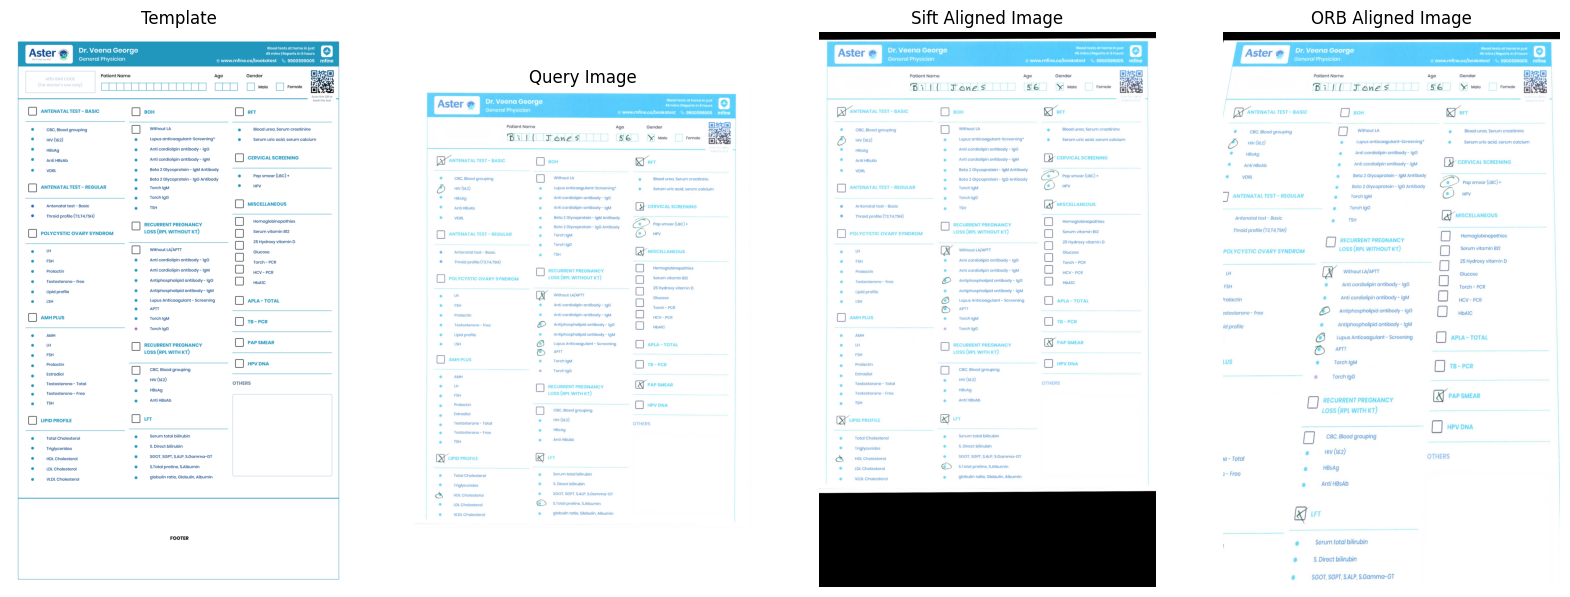

In [39]:
import urllib.request
import numpy as np

def gcp_file_to_image(filename):
    gcp_url = f"https://storage.googleapis.com/rich_object_detection/submissions/{filename}"
    try:
        resp = urllib.request.urlopen(gcp_url)
        image = np.asarray(bytearray(resp.read()), dtype="uint8")
        image = cv2.imdecode(image, cv2.IMREAD_COLOR)
        return image
    except Exception as e:
        print(f"Error reading image from URL: {e}")
        return None

# from fs_gcsfs import GCSFS
# gcsfs = GCSFS(bucket_name="rich_object_detection")

# lifecell_query = os.path.join(photo_dir, "image_snap_1660127120112.jpeg")

# query_1 = os.path.join(photo_dir, "image_snap_1660127120112.jpeg")
# query_1 = open_fs(f"{submitted_photo_dir}/TRF-1-BillJones-scanned.JPG")
query = gcp_file_to_image("TRF-1-BillJones-scanned.JPG")

# query_1 = os.path.join(lifecell_im_dir, "image_snap_1660127731056.jpeg")
# query_1 = os.path.join(lifecell_im_dir, "image_snap_1660127881470.jpeg")
# query_1 = os.path.join(lifecell_im_dir, "image_snap_1660127845671.jpeg")
# query_1 = os.path.join(lifecell_im_dir, "image_snap_1660127805865.jpeg")

# query = cv2.imread()

aligned_sift = sift_aligner.align(query)
aligned_orb = orb_aligner.align(query)

plt.figure(figsize=(20,20))

ax4 = plt.subplot(141)
ax4.axis('off')
ax4.set_title("Template")
ax4.imshow(cv2.cvtColor(cv2.imread(lifecell_template_path), cv2.COLOR_BGR2RGB))

ax1 = plt.subplot(142)
ax1.axis('off')
ax1.set_title("Query Image")
ax1.imshow(cv2.cvtColor(query, cv2.COLOR_BGR2RGB))

ax2 = plt.subplot(143)
ax2.axis('off')
ax2.set_title("Sift Aligned Image")
ax2.imshow(cv2.cvtColor(aligned_sift, cv2.COLOR_BGR2RGB))

ax3 = plt.subplot(144)
ax3.axis('off')
ax3.set_title('ORB Aligned Image')
ax3.imshow(cv2.cvtColor(aligned_orb, cv2.COLOR_BGR2RGB))

In [4]:
h, w, _  = aligned_sift.shape

tp_count = h*w

gray = cv2.cvtColor(aligned_sift, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

sift_black_count = 1 - (cv2.countNonZero(thresh)/tp_count)
orb_black_count = 1 - (cv2.countNonZero(cv2.cvtColor(aligned_orb, cv2.COLOR_BGR2GRAY))/tp_count)

print(f'Sift Black Count: {sift_black_count}, Orb Black Count: {orb_black_count}')

Sift Black Count: 0.18645924369747902, Orb Black Count: 0.013780042016806715


In [5]:
lifecell_template_im = cv2.imread(lifecell_template_path)
lifecell_template_im.shape

(2800, 1700, 3)

In [6]:
# lifecell_roi_file = "/Users/jaswantjonnada/Documents/TestRequestForm/roi_data/Lifecell_ROI_Box.json"

with open(f"{project_dir}/test_data/TRF-1_annotation.json", "rb") as lifecell_roi_file:
    lifecell_roi = json.load(lifecell_roi_file)



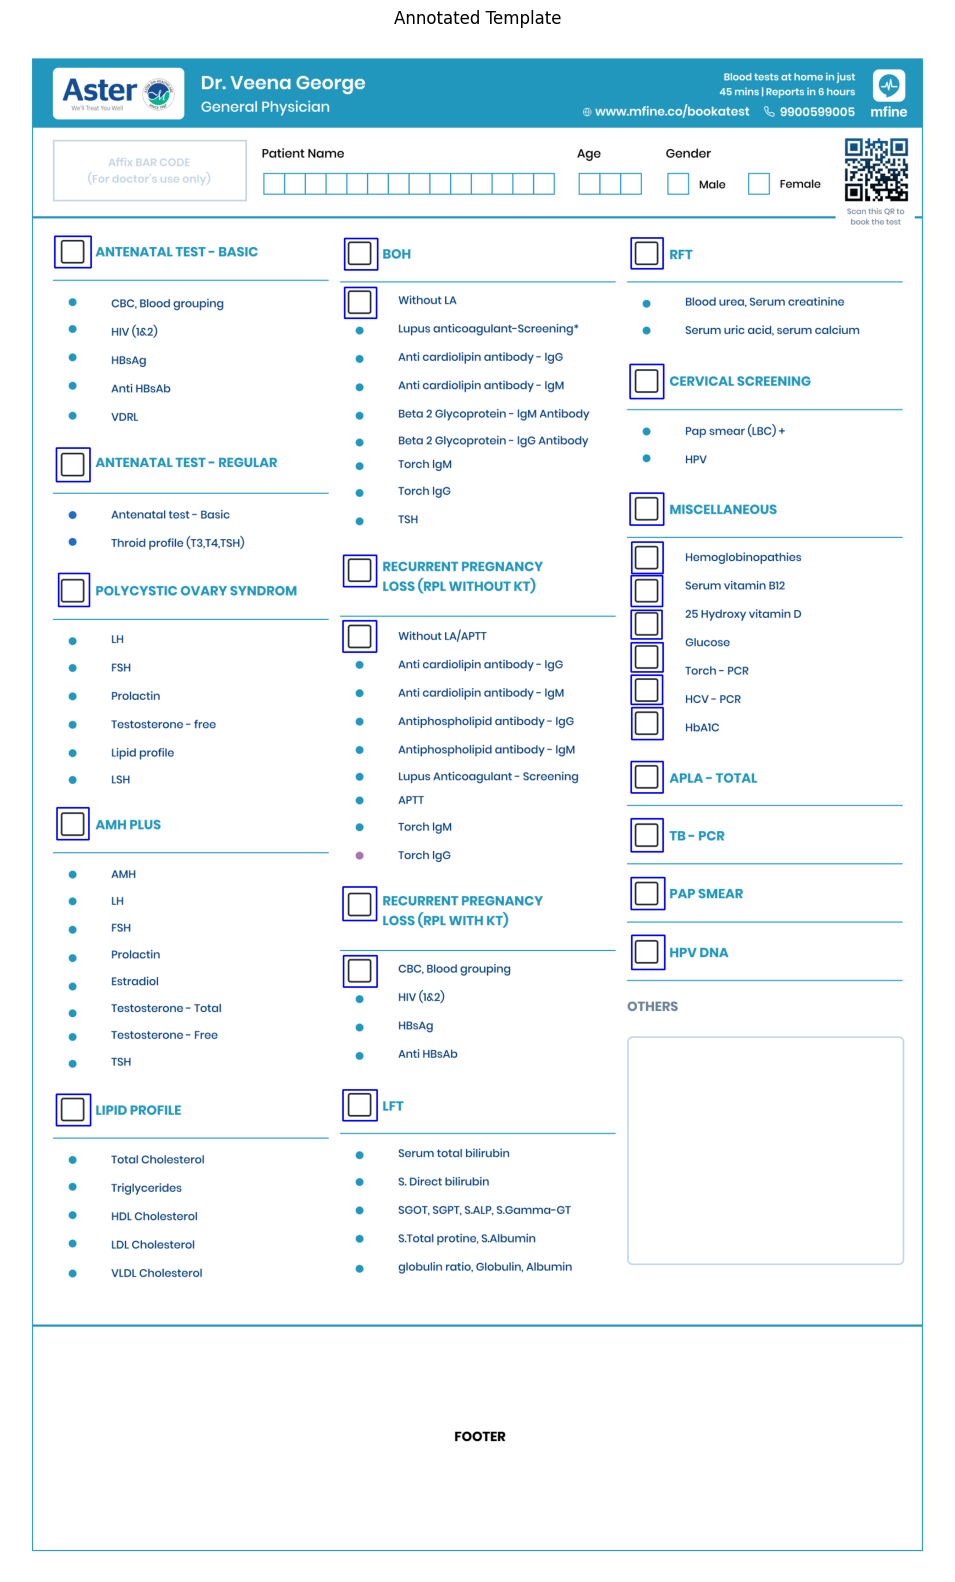

In [7]:

lifecell_template_im_copy = lifecell_template_im.copy()

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    lifecell_template_im_copy = cv2.rectangle(lifecell_template_im_copy, (x, y), (x+w, y+h), (255,0,0), 2)

plt.figure(figsize=(20, 20))
plt.axis('off')
plt.title("Annotated Template")
plt.imshow(cv2.cvtColor(lifecell_template_im_copy, cv2.COLOR_BGR2RGB))

In [8]:
aligned_sift_copy = aligned_sift.copy()
aligned_orb_copy = aligned_orb.copy()

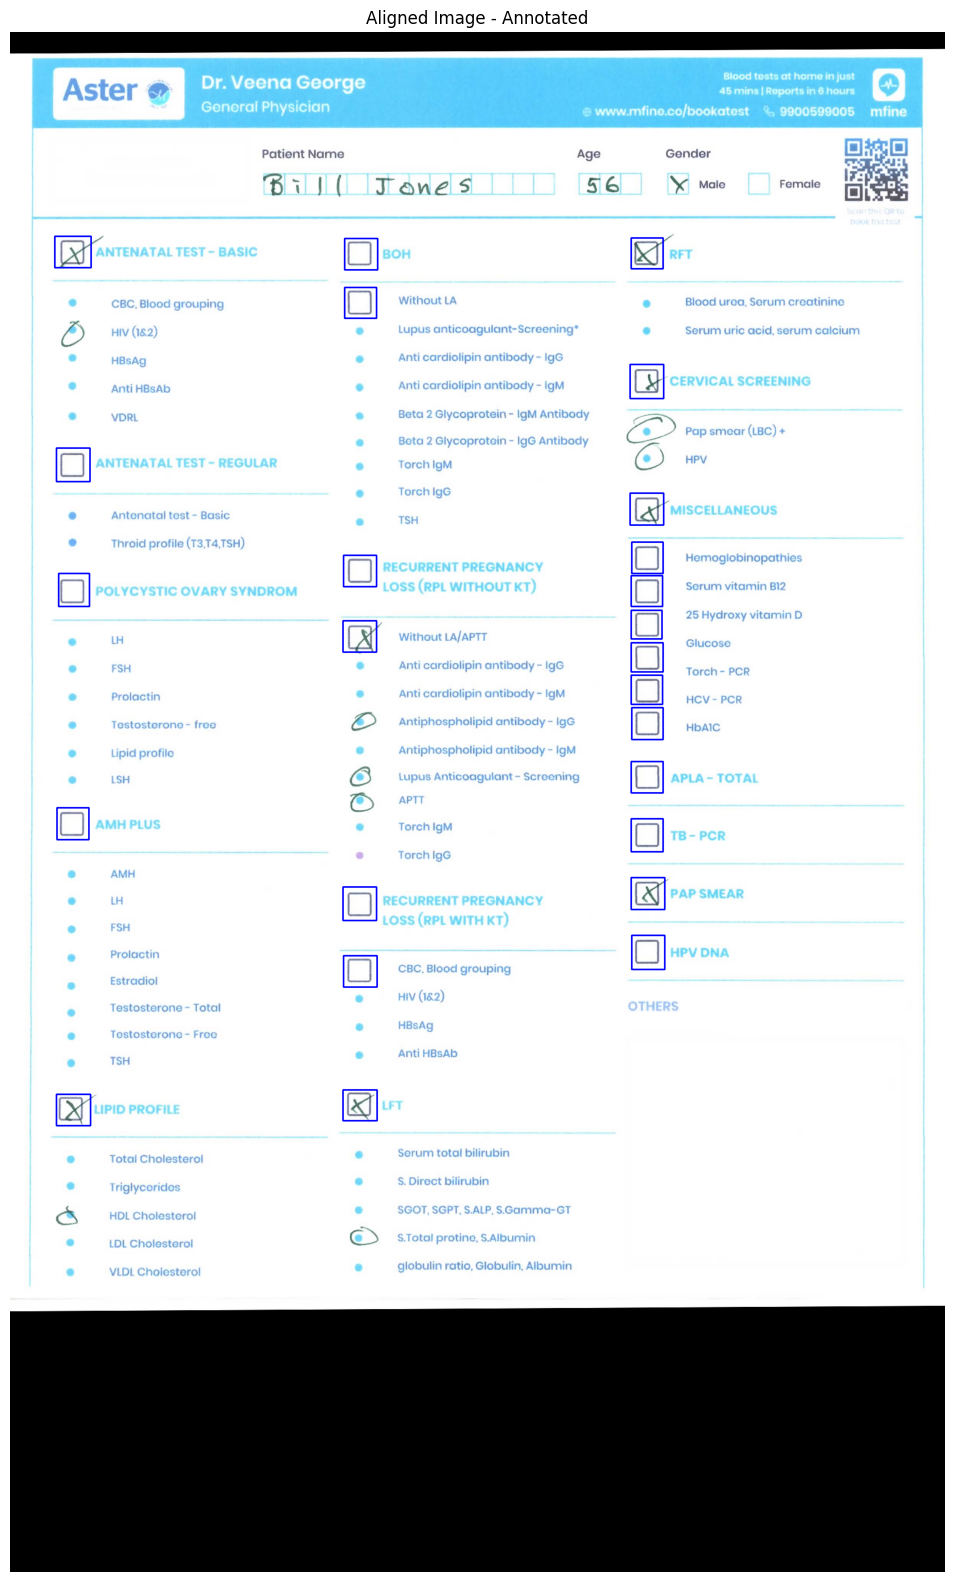

In [9]:

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    aligned_sift_copy = cv2.rectangle(aligned_sift_copy, (x, y), (x+w, y+h), (255,0,0), 2)

plt.figure(figsize=(20, 20))
plt.axis('off')
plt.title("Aligned Image - Annotated")
plt.imshow(cv2.cvtColor(aligned_sift_copy, cv2.COLOR_BGR2RGB))

In [10]:
aligned_sift_copy_1 = aligned_sift.copy()

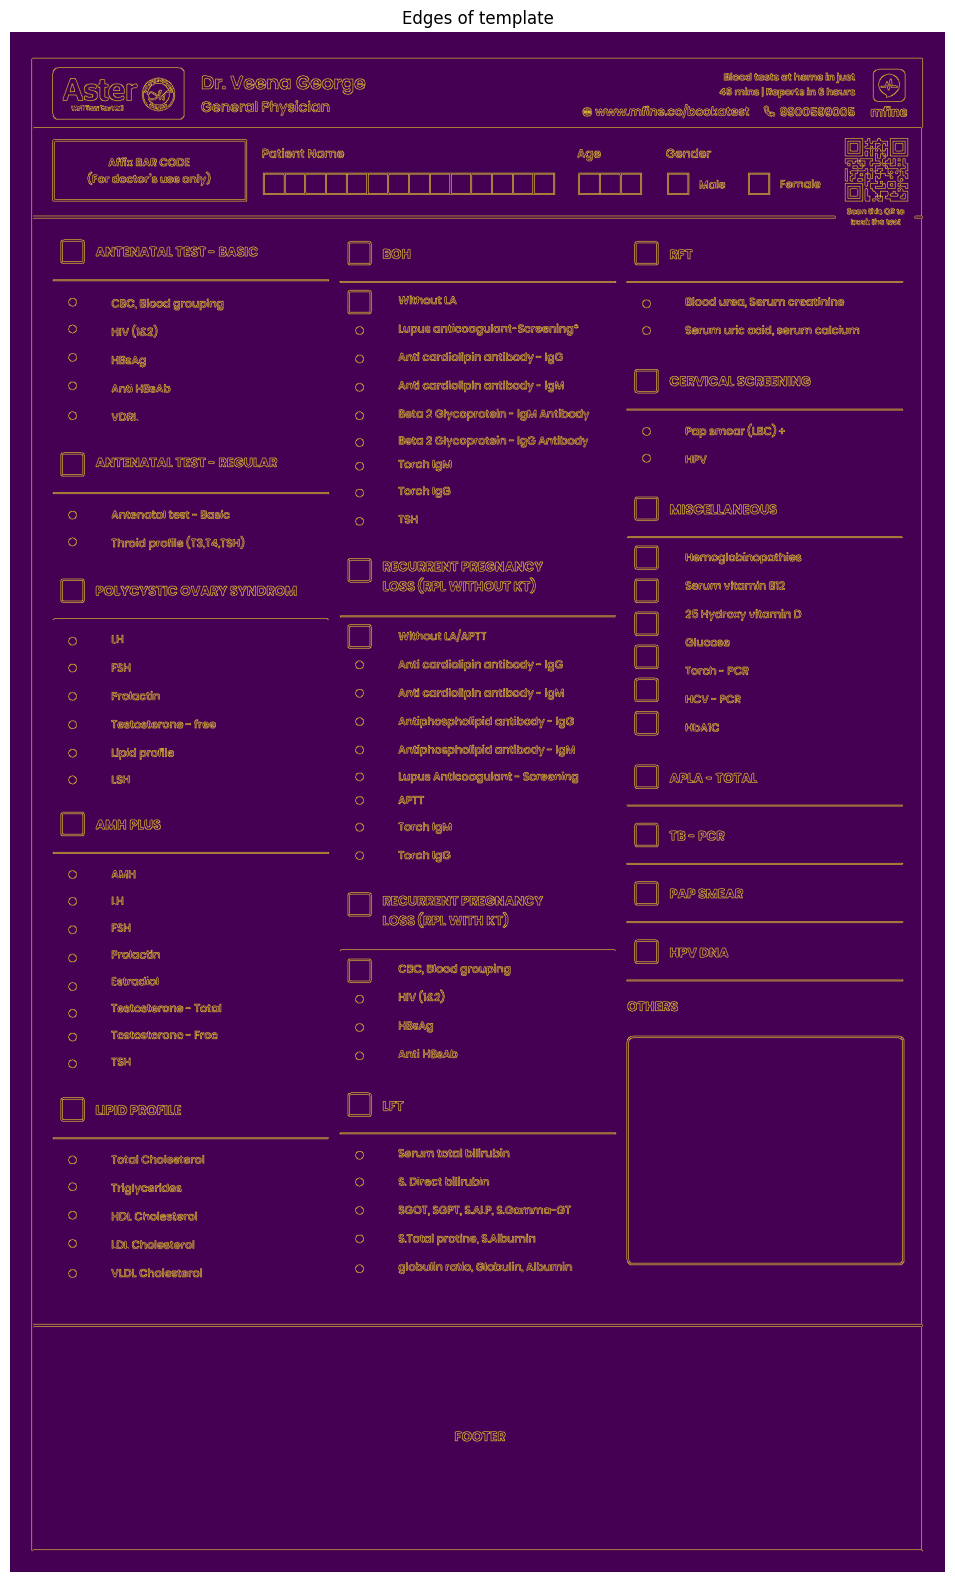

In [11]:
lifecell_template_gray = cv2.cvtColor(lifecell_template_im, cv2.COLOR_BGR2GRAY)
lifecell_template_edges = cv2.Canny(lifecell_template_gray, 100, 200)

plt.figure(figsize=(20,20))
plt.axis('off')
plt.title("Edges of template")
plt.imshow(lifecell_template_edges)

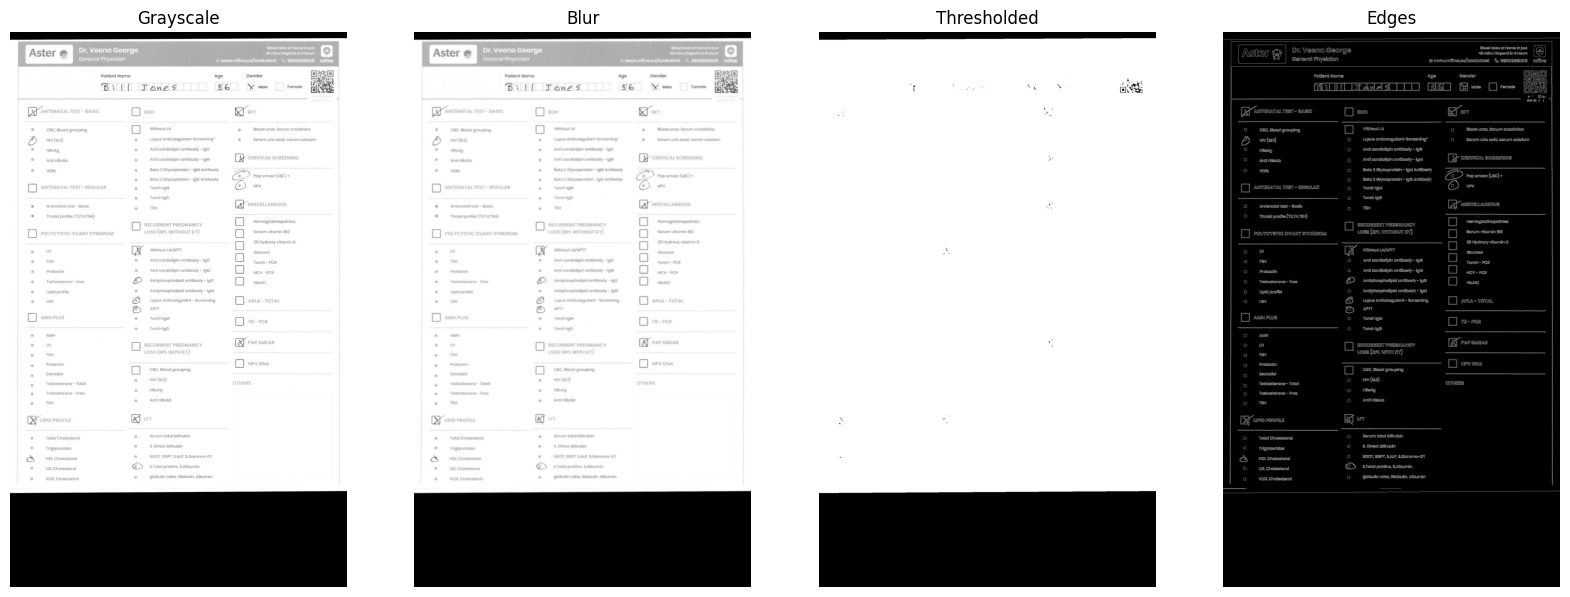

In [12]:
aligned_sift_copy_1_gray = cv2.cvtColor(aligned_sift_copy_1, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(aligned_sift_copy_1_gray, (7, 7), 0)

_, aligned_sift_copy_1_threshold = cv2.threshold(blur, 127, 255, cv2.THRESH_OTSU)

aligned_sift_copy_1_edges = cv2.Canny(aligned_sift_copy_1, 30, 150, apertureSize=3, L2gradient=False)

plt.figure(figsize=(20, 20))

ax1 = plt.subplot(141)
ax1.axis('off')
ax1.set_title('Grayscale')
ax1.imshow(aligned_sift_copy_1_gray, cmap=plt.cm.gray)

ax2 = plt.subplot(142)
ax2.axis('off')
ax2.set_title('Blur')
ax2.imshow(blur, cmap=plt.cm.gray)

ax3 = plt.subplot(143)
ax3.axis('off')
ax3.set_title('Thresholded')
ax3.imshow(aligned_sift_copy_1_threshold, cmap=plt.cm.gray)

ax4 = plt.subplot(144)
ax4.axis('off')
ax4.set_title('Edges')
ax4.imshow(aligned_sift_copy_1_edges, cmap=plt.cm.gray)


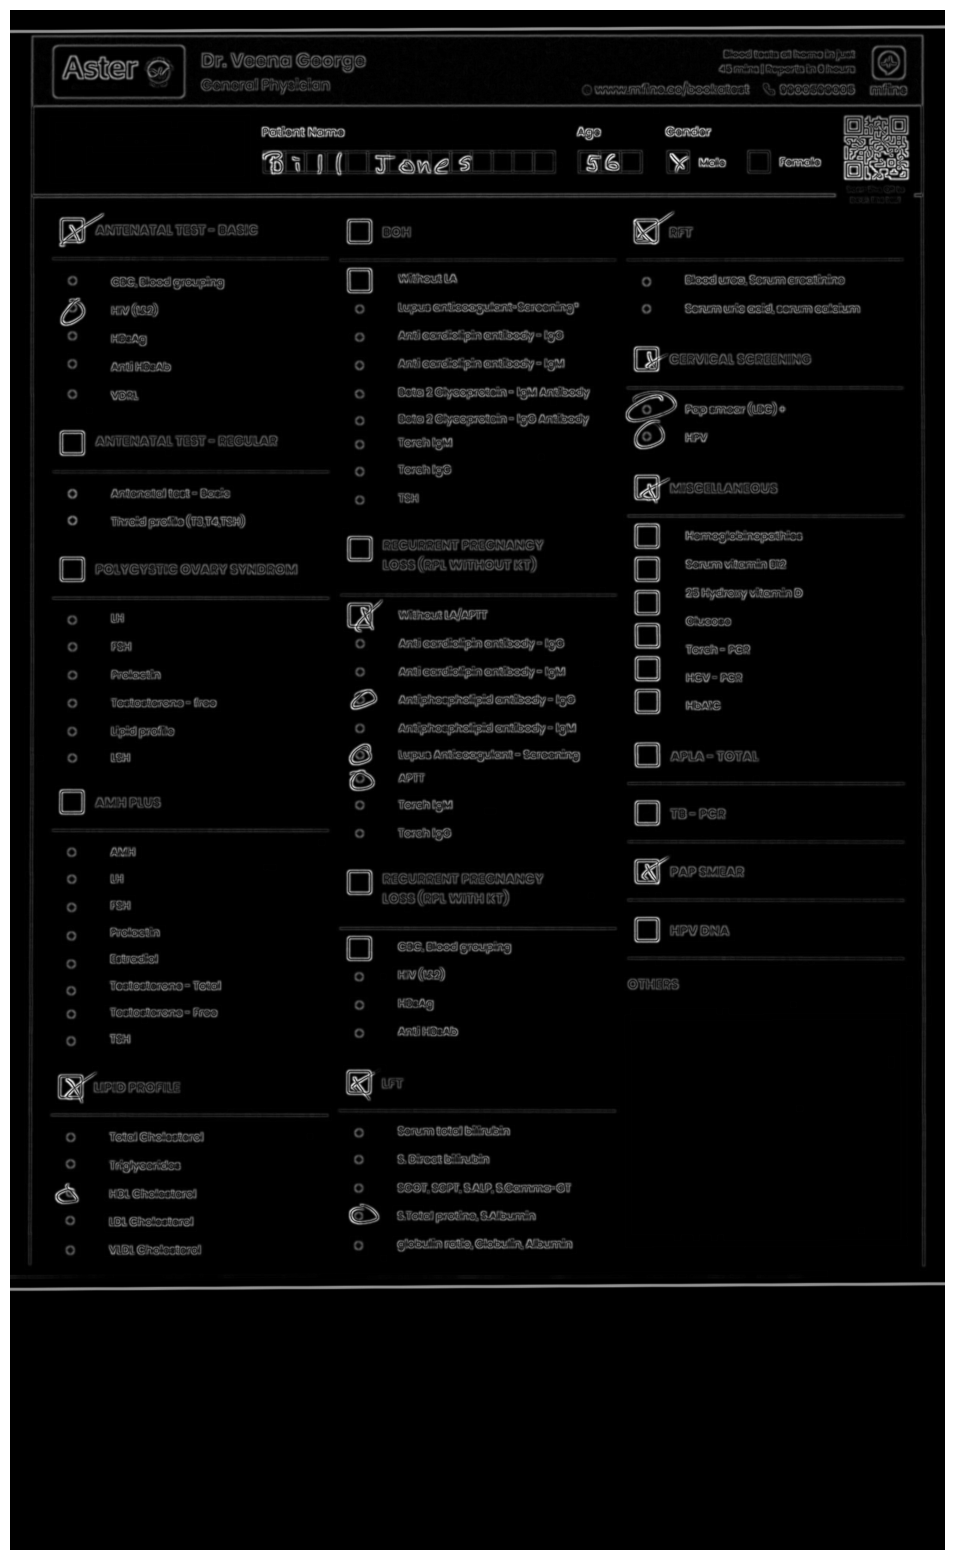

In [13]:
gray = cv2.cvtColor(aligned_sift_copy_1, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
x = cv2.Sobel(blur, cv2.CV_64F, 1,0, ksize=3, scale=1)
y = cv2.Sobel(blur, cv2.CV_64F, 0,1, ksize=3, scale=1)
absx= cv2.convertScaleAbs(x)
absy = cv2.convertScaleAbs(y)
edge = cv2.addWeighted(absx, 0.5, absy, 0.5,0)

plt.figure(figsize=(20,20))
plt.axis('off')
plt.imshow(edge, cmap=plt.cm.gray)



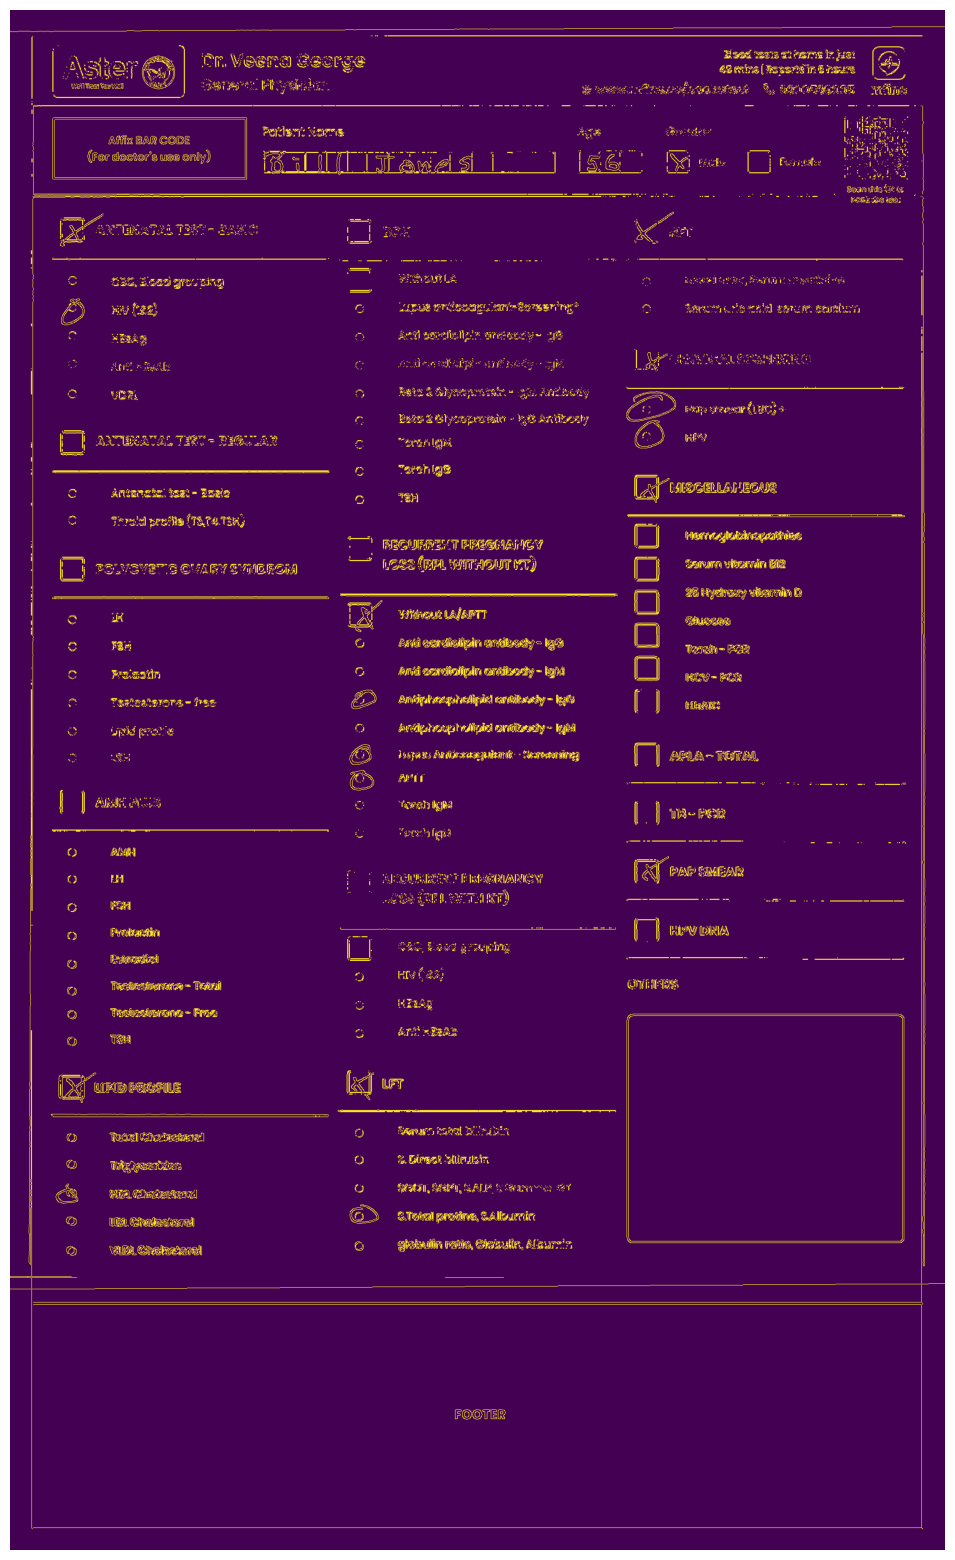

In [14]:
image_diff = cv2.absdiff(lifecell_template_edges, aligned_sift_copy_1_edges)

plt.figure(figsize=(20, 20))
plt.axis('off')
plt.imshow(image_diff)


['Antenatal Test - Basic', 'Antenatal Test - Regular', 'Polycystic Ovary Syndrome', 'AMH Plus', 'Lipid Profile', 'BOH ', 'BOH without LA', 'Recurrent Pregnancy Loss (RPL without KT)', 'Recurrent Pregnancy Loss (RPL without KT) without LA/APTT', 'Recurrent Pregnancy Loss (RPL with KT)', 'CBC, Blood grouping', 'LFT', 'RFT', 'Cervical Screening', 'Misceullaneous', 'Hemoglobinopathies', 'Serum Vitamin B12', '25 Hydroxy Vitamin D ', 'Glucose', 'TORCH - PCR', 'HCV - PCR', 'APLA-TOTAL', 'TB-PCR', 'Pap Smear', 'HPV DNA']


/var/folders/7_/5qvvh9jj4wz05stn062204y00000gn/T/ipykernel_71503/3838473187.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(2, 2))


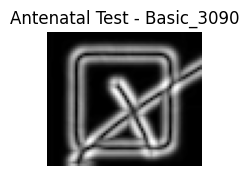

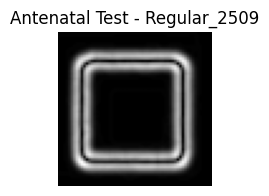

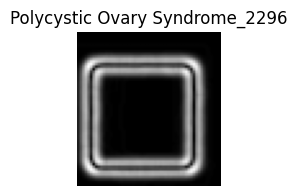

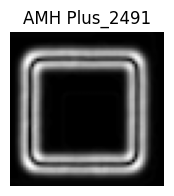

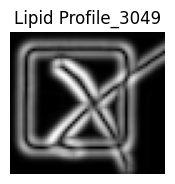

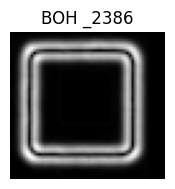

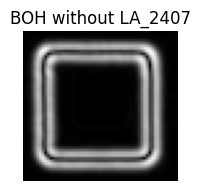

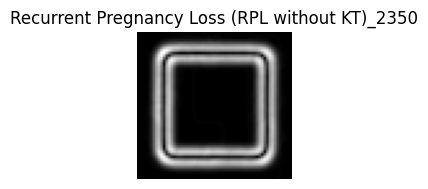

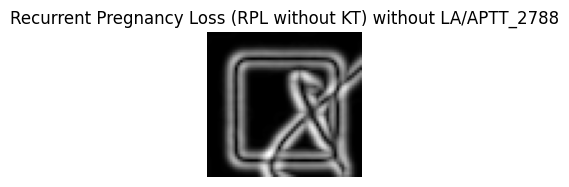

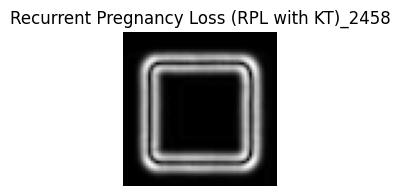

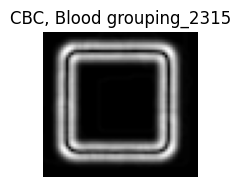

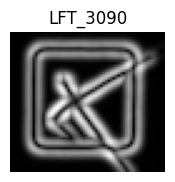

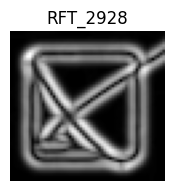

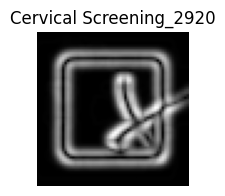

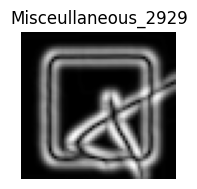

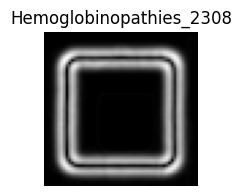

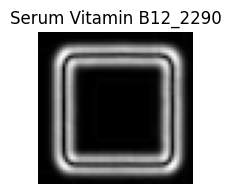

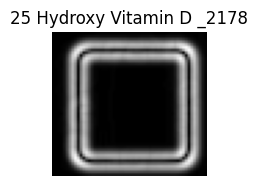

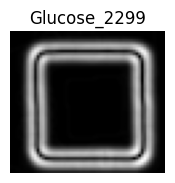

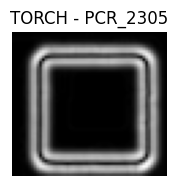

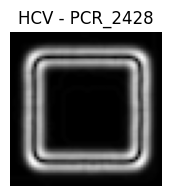

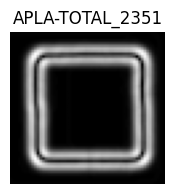

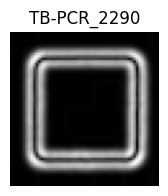

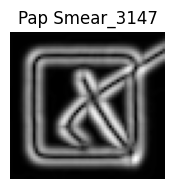

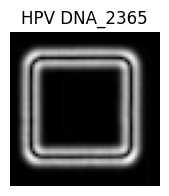

In [15]:

regions = []

non_black_count_threshold = 90

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']
    sample_region = sample['region_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    # print(f'Point 1 ({x},{y}), Point 2: ({x+w}, {y+h})')

    # im = aligned_sift_copy_1_edges[y:y+h, x:x+w]
    im = edge[y: y+h, x:x+w]
    non_black_count = cv2.countNonZero(im)

    if non_black_count > non_black_count_threshold:
        regions.append(sample_region['type'])

    title = f'{sample_region["type"]}_{non_black_count}'
    # plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))

    try:
        plt.figure(figsize=(2, 2))
        plt.title(title)
        plt.axis("off")
        plt.imshow(im, cmap = plt.cm.gray)
    except ValueError:
        print('Value Error')

print(regions)

    

### Removing horizontal and vertical lines

Detected Lines Length: 2800, Contours Length: 2


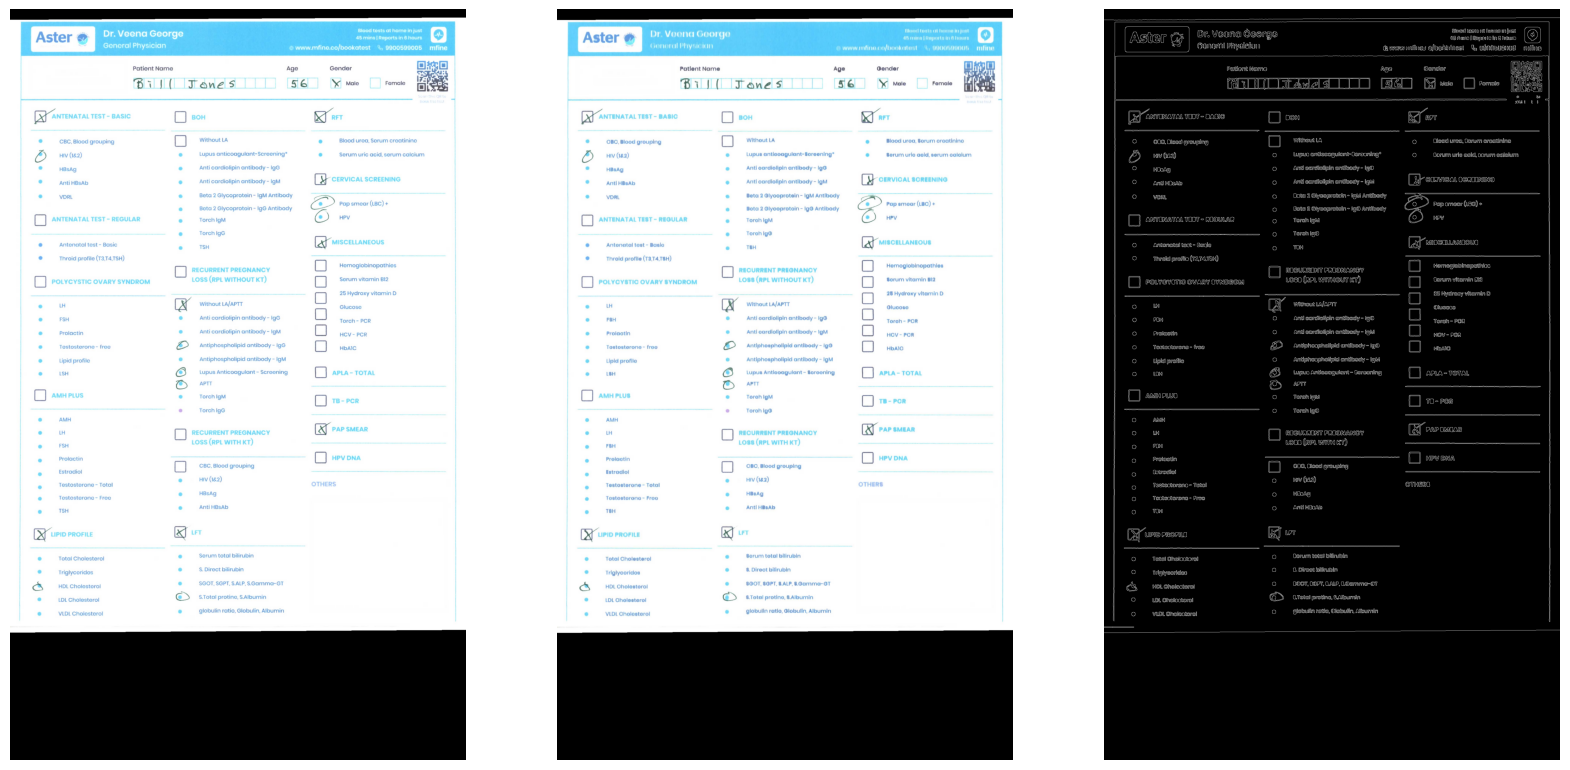

In [16]:
aligned_sift_copy_2 = aligned_sift.copy()

gray = cv2.cvtColor(aligned_sift_copy_2, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25,1))
detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)


cnts = cv2.findContours(detected_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f'Detected Lines Length: {len(detected_lines)}, Contours Length: {len(cnts[0])}')
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(aligned_sift_copy_2, [c], -1, (0,0,0), 2)

repair_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,6))
result = 255 - cv2.morphologyEx(255 - aligned_sift_copy_2, cv2.MORPH_CLOSE, repair_kernel, iterations=1)

canny = cv2.Canny(result, 30, 180)

plt.figure(figsize=(20, 20))
ax1 = plt.subplot(131)
ax1.axis('off')
ax1.imshow(cv2.cvtColor(aligned_sift_copy_2, cv2.COLOR_BGR2RGB))

ax2 = plt.subplot(132)
ax2.axis('off')
ax2.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

ax3 = plt.subplot(133)
ax3.axis('off')
ax3.imshow(canny, cmap=plt.cm.gray)


### Morphology operation and subtracting it from the image

Image Preprocessing - OTSU Thresholding 

1. Find Horizontal Line using Morphology
2. Find Vertical Lines using Morphology
3. Subtract Horizontal Lines from the thresholded image
4. Subtract Vertical Lines from the thrsholded image
5. Subtract both Horizontal Lines and Vertical Lines from thresholded Image

/var/folders/7_/5qvvh9jj4wz05stn062204y00000gn/T/ipykernel_71503/3609112455.py:77: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(16, 8))


[]


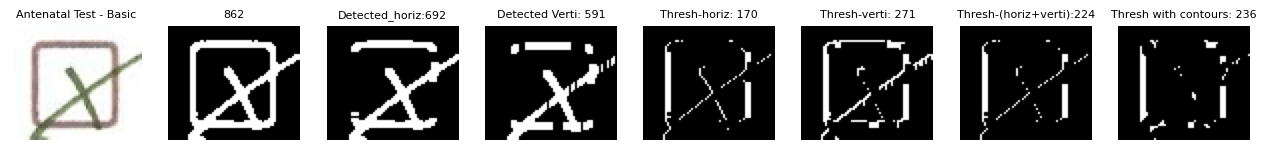

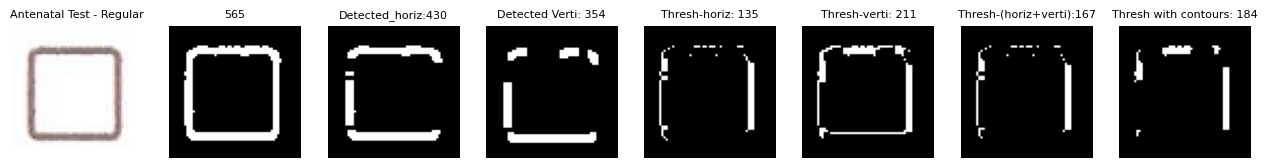

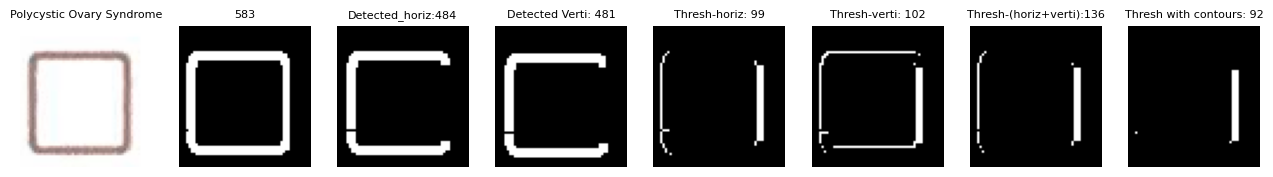

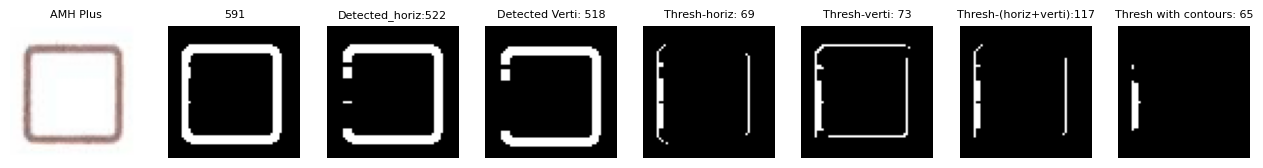

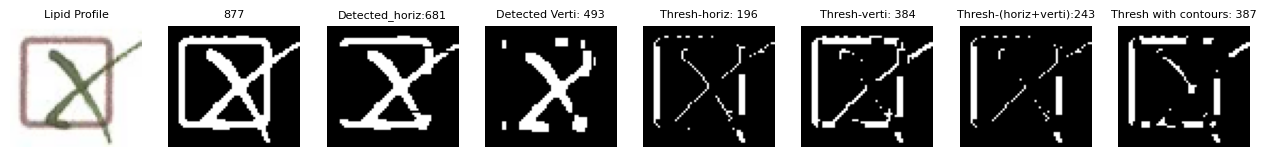

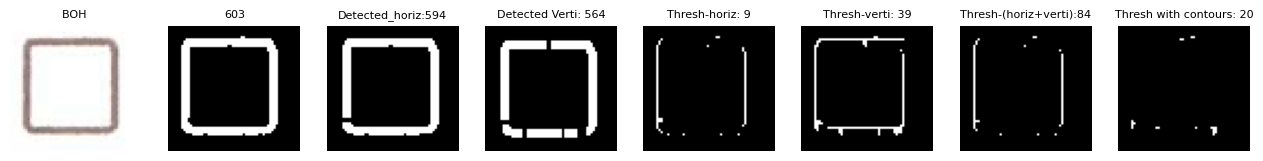

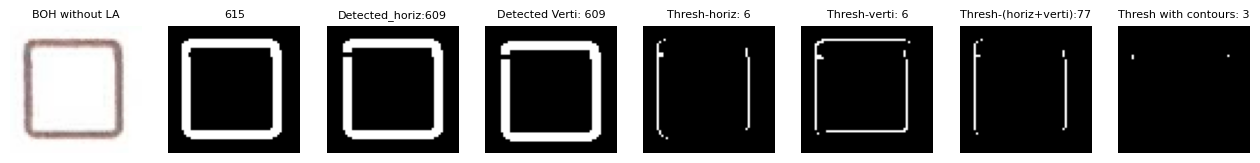

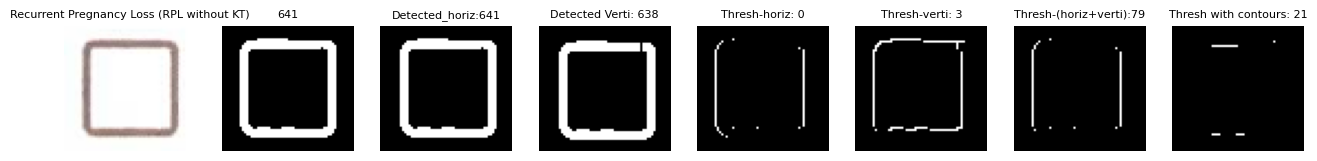

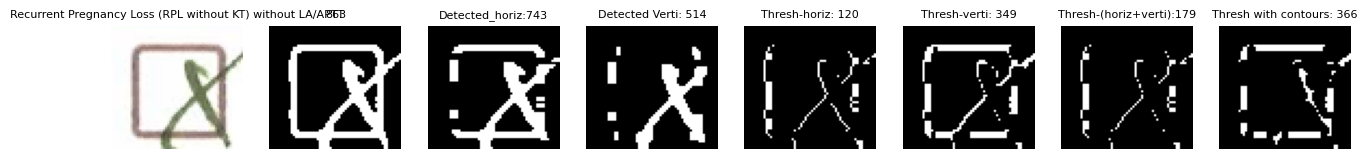

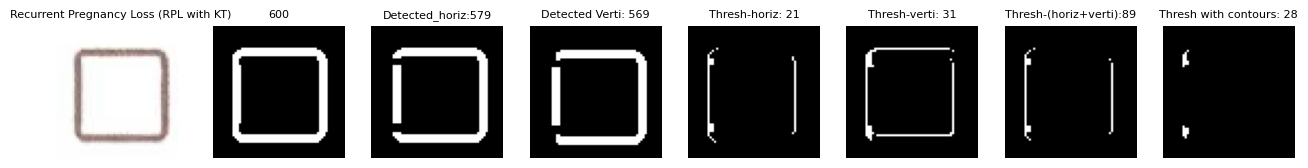

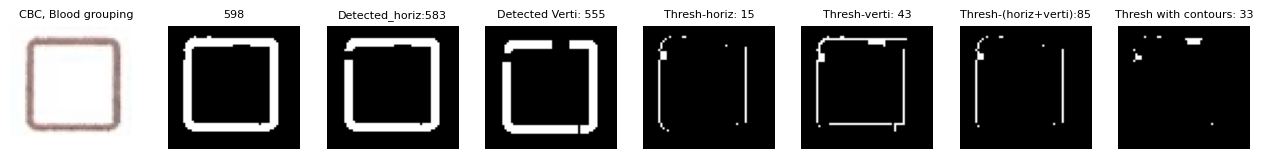

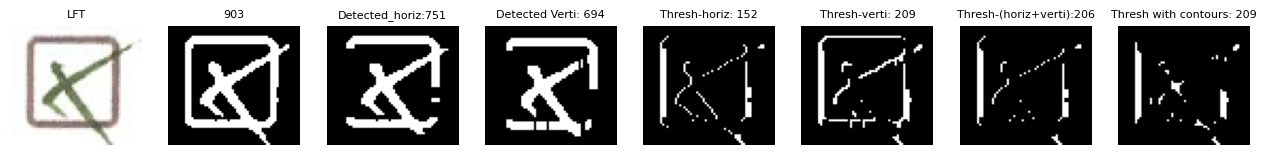

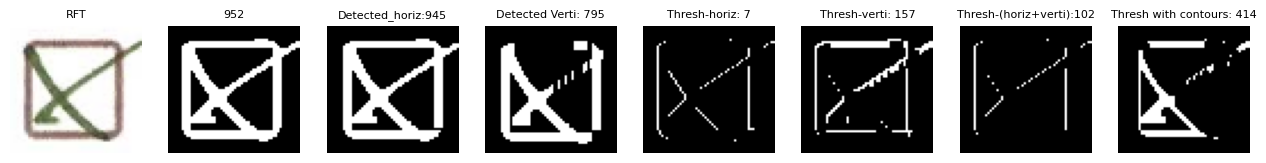

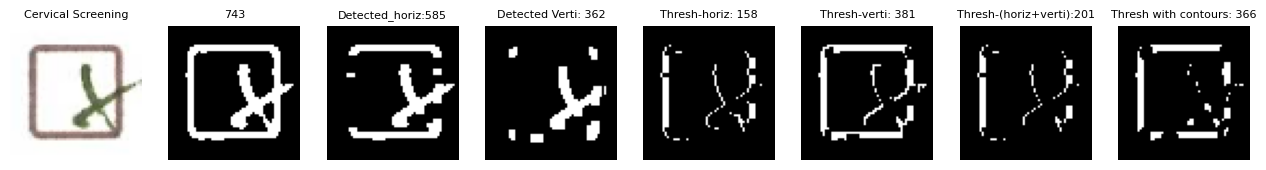

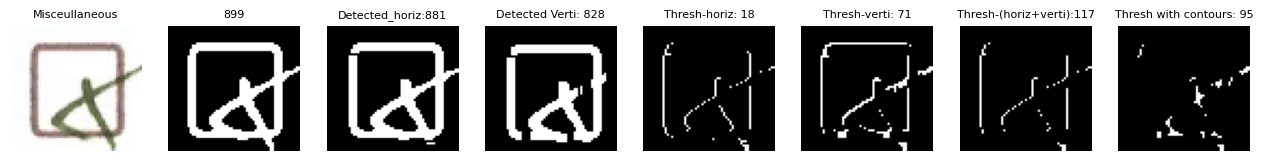

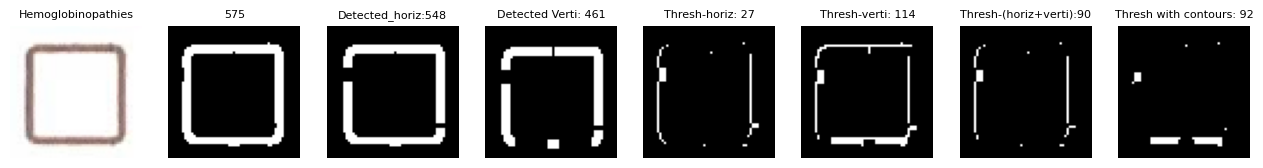

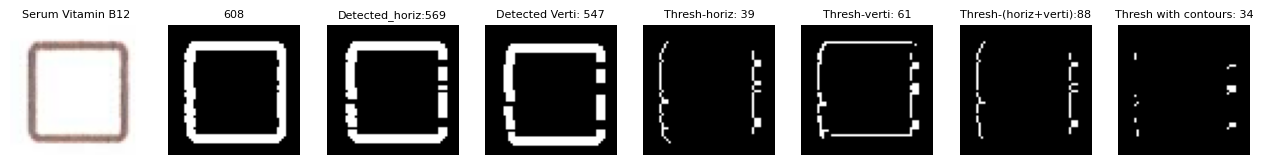

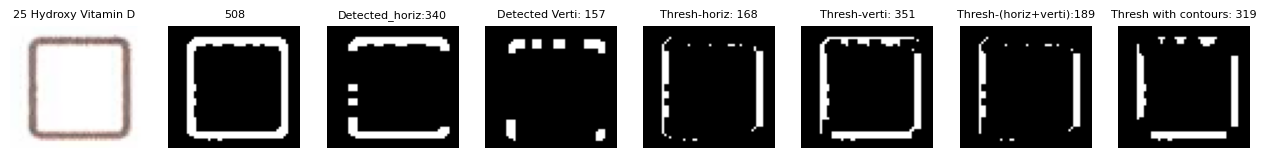

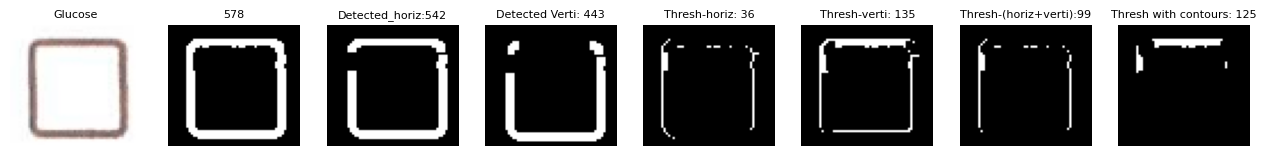

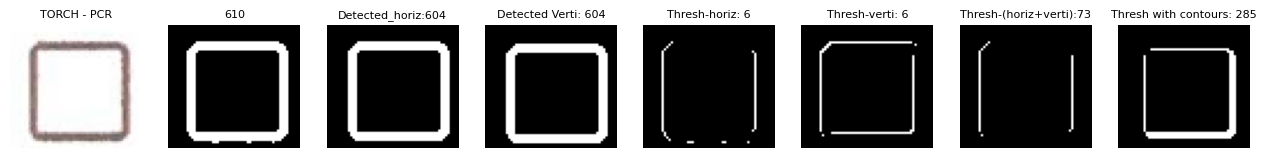

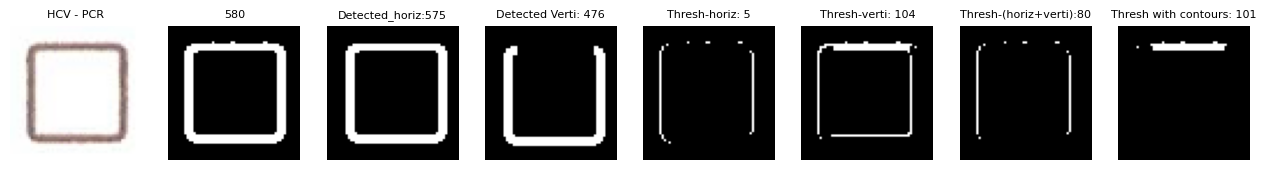

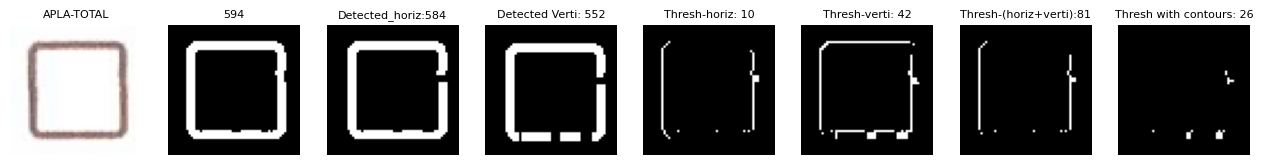

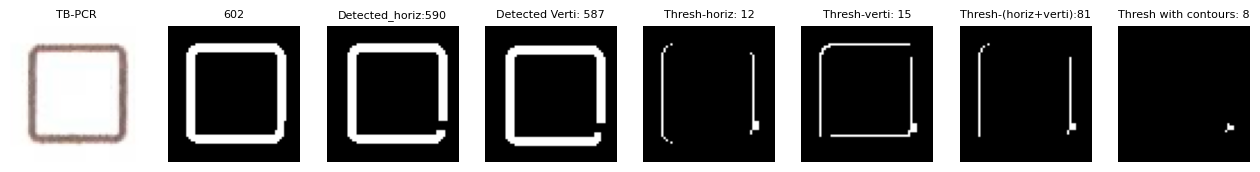

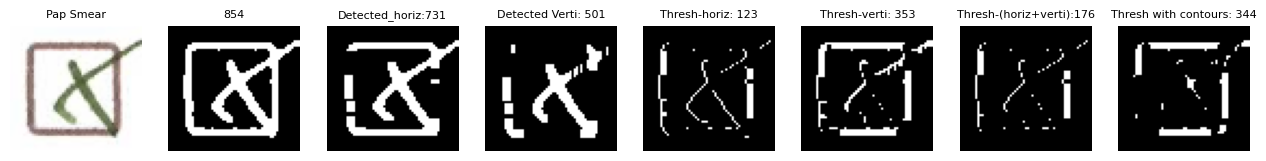

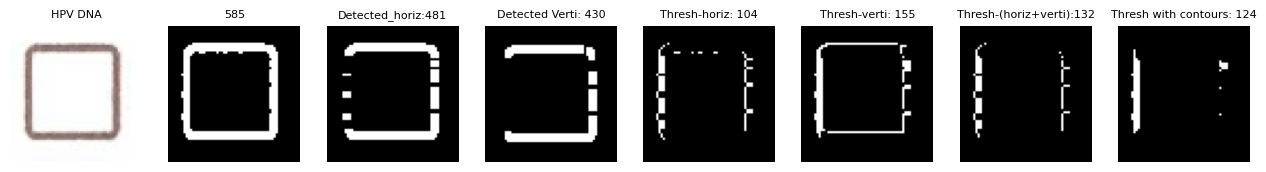

In [17]:

# https://stackoverflow.com/questions/55763858/how-to-detect-and-find-checkboxes-in-a-form-using-python-opencv


aligned_sift_copy_3 = aligned_sift.copy()


regions = []

non_black_count_threshold = 90

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']
    sample_region = sample['region_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    # print(f'Point 1 ({x},{y}), Point 2: ({x+w}, {y+h})')

    # im = aligned_sift_copy_1_edges[y:y+h, x:x+w]
    im = aligned_sift_copy_3[y:y+h, x:x+w]
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    se=cv2.getStructuringElement(cv2.MORPH_RECT , (7,7))
    

    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.threshold(blur, 180, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    thresh = 255 - thresh
    thresh_copy = thresh.copy()
    

    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4,1))
    detected_horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)

    # cnts = cv2.findContours(detected_horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # # print(f'Detected Horizontal Lines Length: {len(detected_horizontal_lines)}, Contours Length: {len(cnts[0])}')
    # cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    # for c in cnts:
    #     cv2.drawContours(thresh_copy, [c], -1, (0,0,0), 2)

    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,4))
    detected_vertical_lines = cv2.morphologyEx(detected_horizontal_lines, cv2.MORPH_OPEN, vertical_kernel, iterations=1)
    
    cnts = cv2.findContours(detected_vertical_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # print(f'Detected Vertical Lines Length: {len(detected_vertical_lines)}, Contours Length: {len(cnts[0])}')
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    for c in cnts:
        cv2.drawContours(thresh_copy, [c], -1, (0,0,0), 2)

    vertical_count = cv2.countNonZero(detected_vertical_lines)
    horizontal_count = cv2.countNonZero(detected_horizontal_lines)
    thresh_count = cv2.countNonZero(thresh)

    thresh_minus_horiz = cv2.subtract(thresh, detected_horizontal_lines)
    thresh_minus_verti = cv2.subtract(thresh, detected_vertical_lines)
    thresh_minus_horiz_verti = cv2.subtract(cv2.subtract(thresh, detected_horizontal_lines), detected_vertical_lines)

    open = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, se, iterations=4)
    # kernel = np.ones((2,2), np.uint8)  
    # img_erosion = cv2.erode(thresh, kernel, iterations=1)  
    # non_black_count = 0
    canny = cv2.Canny(thresh, 100, 150, apertureSize=3, L2gradient=True)

    non_black_count = cv2.countNonZero(thresh_minus_horiz_verti)
    # if non_black_count > non_black_count_threshold:
    #     regions.append(sample_region['type'])

    title = f'{sample_region["type"]}_{non_black_count}'
    # plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))

    # print(f'Region: {sample_region["type"]}, Threshold Count: {thresh_count}, Vertical Count: {vertical_count}, Horizontal Count: {horizontal_count}, Final Image Count: {non_black_count}')

    try:
        plt.figure(figsize=(16, 8))

        ax1 = plt.subplot(181)
        ax1.set_title(f'{sample_region["type"]}', size=8)
        ax1.axis('off')
        ax1.imshow(im, cmap=plt.cm.gray)
        
        ax2 = plt.subplot(182)
        ax2.axis('off')
        ax2.set_title(f'{thresh_count}', size=8)
        ax2.imshow(thresh, cmap=plt.cm.gray)

        ax3 = plt.subplot(183)
        ax3.axis('off')
        ax3.set_title(f'Detected_horiz:{horizontal_count}', size=8)
        ax3.imshow(detected_horizontal_lines, cmap=plt.cm.gray)

        ax4 = plt.subplot(184)
        ax4.axis('off')
        ax4.set_title(f'Detected Verti: {vertical_count}', size=8)
        ax4.imshow(detected_vertical_lines, cmap=plt.cm.gray)

        ax5 = plt.subplot(185)
        ax5.axis('off')
        ax5.set_title(f'Thresh-horiz: {thresh_count - horizontal_count}', size=8)
        ax5.imshow(thresh_minus_horiz, cmap=plt.cm.gray)

        ax6 = plt.subplot(186)
        ax6.axis('off')
        ax6.set_title(f'Thresh-verti: {thresh_count - vertical_count}', size=8)
        ax6.imshow(thresh_minus_verti, cmap=plt.cm.gray)
        
        ax7 = plt.subplot(187)
        ax7.axis('off')
        ax7.set_title(f'Thresh-(horiz+verti):{non_black_count}', size=8)
        ax7.imshow(thresh_minus_horiz_verti, cmap=plt.cm.gray)

        ax8 = plt.subplot(188)
        ax8.axis('off')
        ax8.set_title(f'Thresh with contours: {cv2.countNonZero(thresh_copy)}', size=8)
        ax8.imshow(thresh_copy, cmap=plt.cm.gray)

    except ValueError:
        print('Value Error')

print(regions)


### Trying hough line transforms

To detect the horizontal and vertical lines

/var/folders/7_/5qvvh9jj4wz05stn062204y00000gn/T/ipykernel_71503/1441057553.py:52: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7,7))


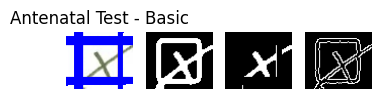

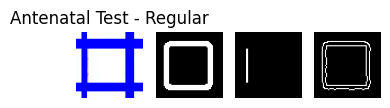

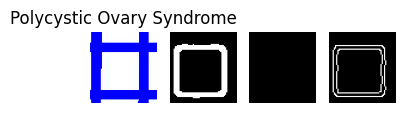

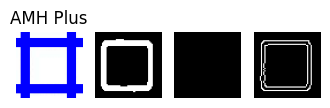

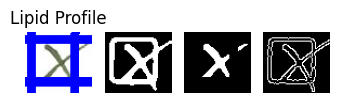

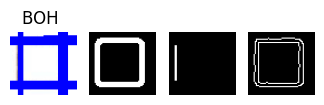

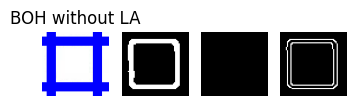

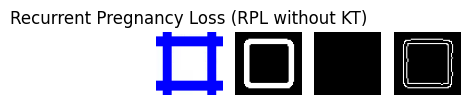

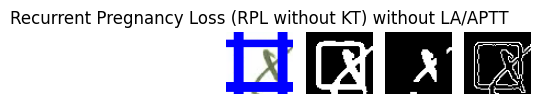

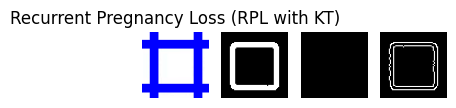

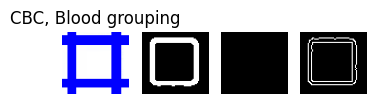

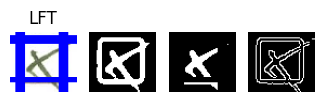

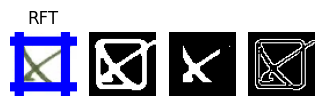

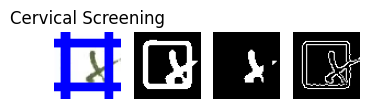

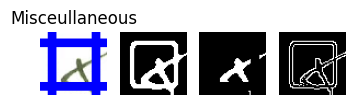

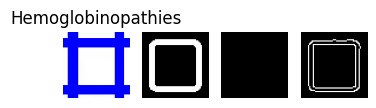

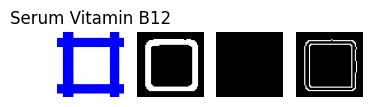

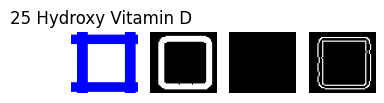

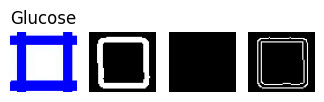

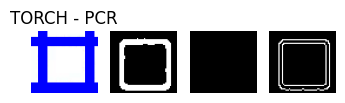

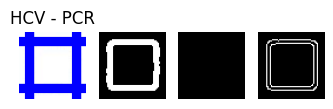

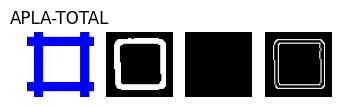

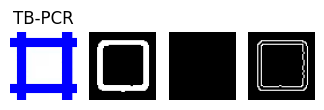

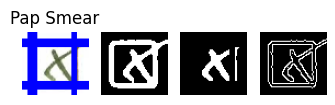

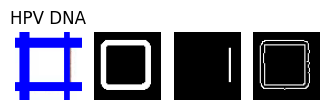

In [18]:

aligned_sift_copy_4 = aligned_sift.copy()

regions = []

non_black_count_threshold = 90

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']
    sample_region = sample['region_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    im = aligned_sift_copy_4[y:y+h, x:x+w]
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    thresh = 255 - thresh
    thresh_copy = thresh.copy()
    edges = cv2.Canny(gray, 50, 100, apertureSize=3)

    lines = cv2.HoughLines(edges,1, np.pi/180, 22, None, 0, 0 )
    
    if lines is not None:
        # print(f'No of lines: {len(lines)}')
        for l in lines:
            arr = np.array(l[0], dtype=np.float64)
            r, theta = arr
            # print(theta * 180 / np.pi)
            a = np.cos(theta)
            b = np.sin(theta)

            x0 = a*r
            y0 = b*r

            x1 = int(x0 + 1000*(-b))
            y1 = int(y0 + 1000*(a))
            x2 = int(x0 - 1000*(-b))
            y2 = int(y0 - 1000*(a))

            theta_deg = theta * 180 / np.pi

            if (theta_deg < 1) or  (theta_deg > 89 and theta_deg < 91):

                cv2.line(thresh_copy, (x1, y1), (x2, y2), (0, 0, 0), 3)
                cv2.line(im, (x1, y1), (x2, y2), (0, 0, 255), 3)
    else:
        print('No line detected')

    plt.figure(figsize=(7,7))

    ax1 = plt.subplot(171)
    ax1.set_title(f'{sample_region["type"]}')
    ax1.axis('off')
    ax1.imshow(im, cmap=plt.cm.gray)

    ax2 = plt.subplot(172)
    ax2.axis('off')
    ax2.imshow(thresh, cmap=plt.cm.gray)

    ax3 = plt.subplot(173)
    ax3.axis('off')
    ax3.imshow(thresh_copy, cmap=plt.cm.gray)

    ax4 = plt.subplot(174)
    ax4.axis('off')
    ax4.imshow(edges, cmap=plt.cm.gray)

### Trying Morphology and Contours

With Box Approximation

Image Pre Processing - Threshold with Otsu 

1. Use Morphology to find the vertical lines
2. Use Morphology to find the horizontal lines 
3. Find contours of the above image
4. For each contour found
    a. Check the arc length
    b. Perform box approximation of the contour area
    c. Draw the box


Results are not at all promising

Drawing Rectangle
Drawing Rectangle
Drawing Rectangle
Drawing Rectangle
Drawing Rectangle
Drawing Rectangle
Drawing Rectangle
Drawing Rectangle


/var/folders/7_/5qvvh9jj4wz05stn062204y00000gn/T/ipykernel_71503/1296249109.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 8))


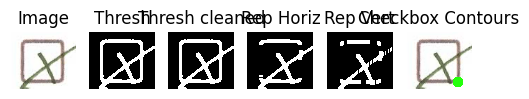

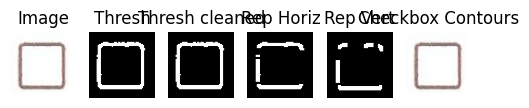

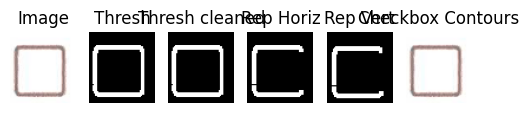

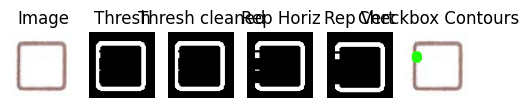

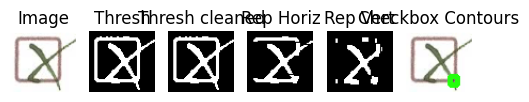

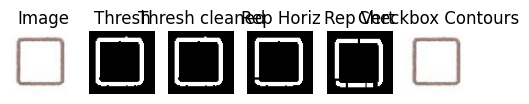

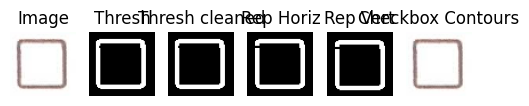

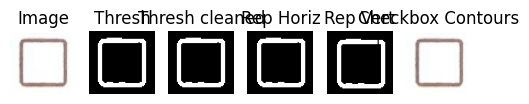

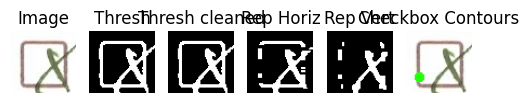

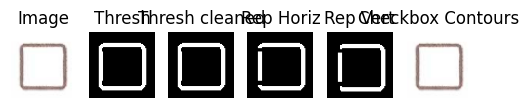

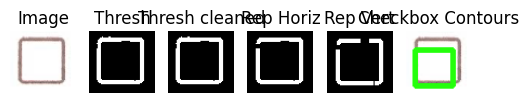

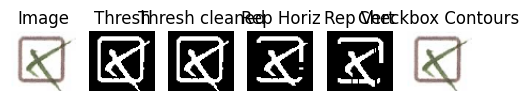

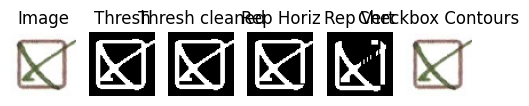

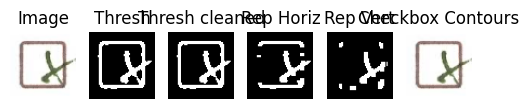

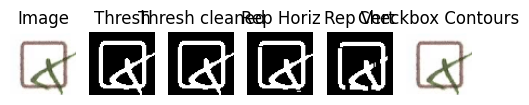

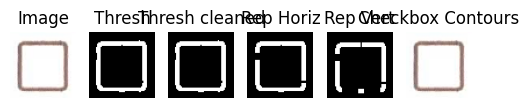

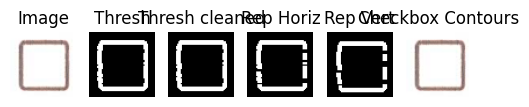

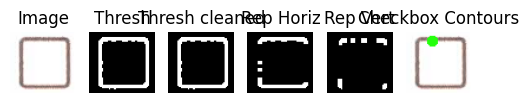

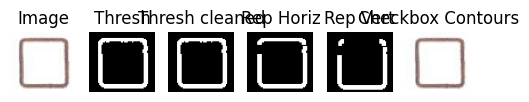

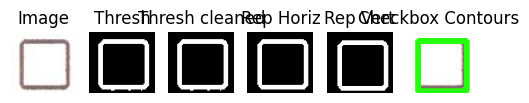

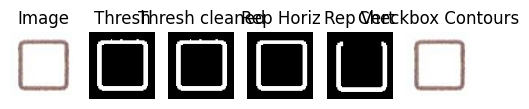

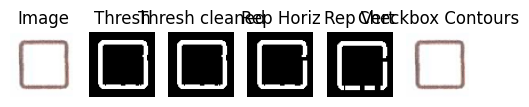

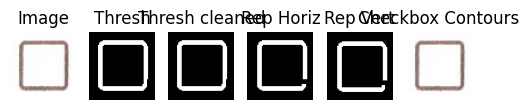

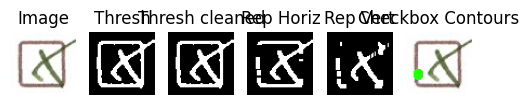

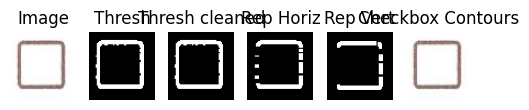

In [19]:

# https://stackoverflow.com/questions/55763858/how-to-detect-and-find-checkboxes-in-a-form-using-python-opencv


aligned_sift_copy_5 = aligned_sift.copy()

regions = []

non_black_count_threshold = 90

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']
    sample_region = sample['region_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    im = aligned_sift_copy_5[y:y+h, x:x+w]
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    se=cv2.getStructuringElement(cv2.MORPH_RECT , (7,7))


    plt.figure(figsize=(8, 8))

    ax1 = plt.subplot(181)
    ax1.set_title("Image")
    ax1.axis('off')
    ax1.imshow(im, cmap=plt.cm.gray)

    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.threshold(blur, 180, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    thresh = 255 - thresh
    
    ax2 = plt.subplot(182)
    ax2.set_title("Thresh")
    ax2.axis('off')
    ax2.imshow(thresh, cmap=plt.cm.gray)
    
    cnts, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
    AREA_THRESHOLD = 10
    for c in cnts:
        area = cv2.contourArea(c)
        if area < AREA_THRESHOLD:
            cv2.drawContours(thresh, [c], -1, 0, -1)

    ax3 = plt.subplot(183)
    ax3.set_title("Thresh cleaned")
    ax3.axis('off')
    ax3.imshow(thresh, cmap=plt.cm.gray)

    repair_kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 1))
    repair_horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, repair_kernel_horizontal, iterations=1)

    ax4 = plt.subplot(184)
    ax4.set_title("Rep Horiz")
    ax4.axis('off')
    ax4.imshow(repair_horizontal, cmap=plt.cm.gray)

    # cnts_horizontal = cv2.findContours(repair_horizontal, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # cnts = cnts_horizontal[0] if len(cnts_horizontal) == 2 else cnts_horizontal[1]
    # for c in cnts:
    #     cv2.drawContours(thresh, [c], -1, (0,0,0), 2)


    repair_kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 4))
    repair_vertical = cv2.morphologyEx(repair_horizontal, cv2.MORPH_OPEN, repair_kernel_vertical, iterations=1)

    ax5 = plt.subplot(185)
    ax5.set_title("Rep Vert")
    ax5.axis('off')
    ax5.imshow(repair_vertical, cmap=plt.cm.gray)
    # cnts_vertical = cv2.findContours(repair_vertical, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # cnts = cnts_vertical[0] if len(cnts_vertical) == 2 else cnts_vertical[1]
    # for c in cnts:
    #     cv2.drawContours(thresh, [c], -1, (0,0,0), 2)

    checkbox_contours = []
    contours, _ = cv2.findContours(repair_vertical, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

    # cnts = cv2.findContours(repair_vertical, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # # print(f'Detected Vertical Lines Length: {len(detected_vertical_lines)}, Contours Length: {len(cnts[0])}')
    # cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    # for c in cnts:
    #     cv2.drawContours(thresh, [c], -1, (0,0,0), 2)

    for cnt in contours:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.035 * peri, True)
        x,y,w,h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)
        # print(f'x: {x}, y: {y}, w:{w}, h:{h}, aspect_ratio: {aspect_ratio}, approx poly dp len: {len(approx)}')
        if len(approx) == 4 and aspect_ratio >= 0.8 and aspect_ratio <= 1.2:
            print("Drawing Rectangle")
            cv2.rectangle(im, (x,y), (x+w, y+h), (36, 255, 12), 3)

    ax6 = plt.subplot(186)
    ax6.set_title("Checkbox Contours")
    ax6.axis('off')
    ax6.imshow(im, cmap=plt.cm.gray)

    # title = f'{sample_region["type"]}_{non_black_count}'
    

    

### Morphology and Hough Transforms 

Hough Transform - filter out only the vertical and horizontal lines

Intial Processing - Use Adaptive thresholding for Binarization. Take the Inverse Image

1. Clean the Image using contours 
2. Find Morphology Horizontal
3. Find Hough Lines and filter only the lines that are Horizontal
4. Find Morphology Vertical
5. Find Hough Lines and filter only the lines that are vertical
6. Draw Horizontal and Vertical lines as Black lines to remove

No Canny Edge Detection is performed. 

The above procedure needs to be done on each patch, not the entire image. It is because, the thresholding and morphology operators will consider the entire image and there will be more operations, when compared to the ROIS

Results look promising, need to evaluate on the entire Dataset


/var/folders/7_/5qvvh9jj4wz05stn062204y00000gn/T/ipykernel_71503/2379398024.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20, 10))


Entities Found:  ['Antenatal Test - Basic', 'Lipid Profile', 'Recurrent Pregnancy Loss (RPL without KT) without LA/APTT', 'LFT', 'RFT', 'Cervical Screening', 'Misceullaneous', 'Pap Smear']


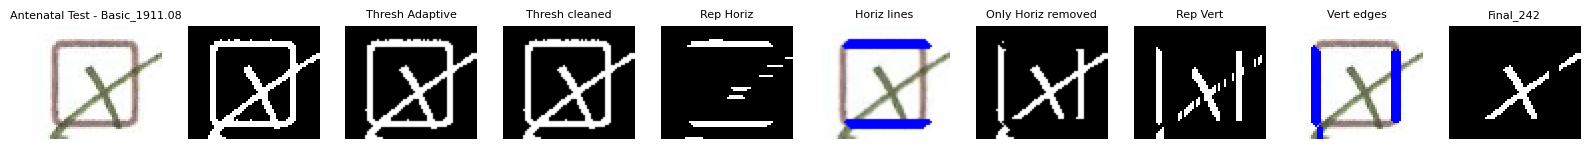

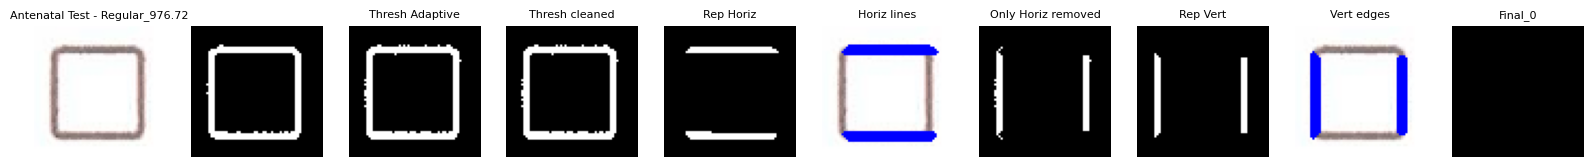

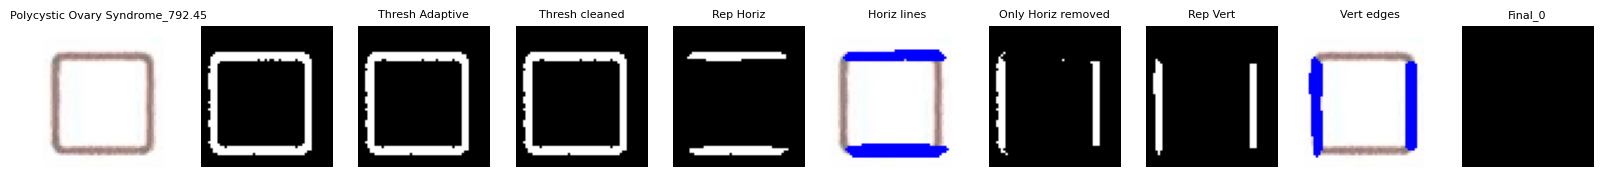

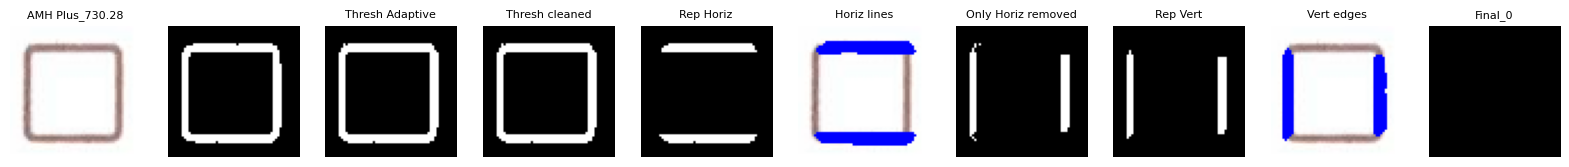

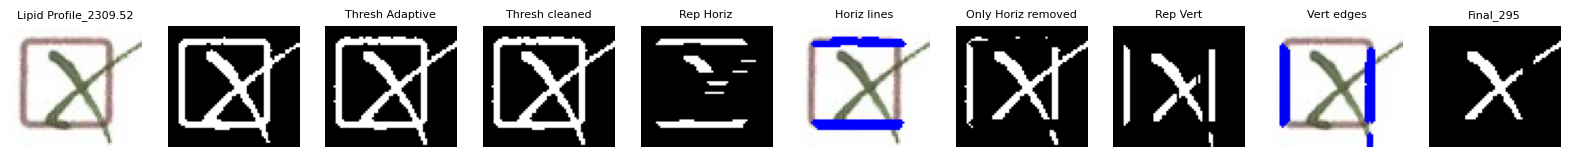

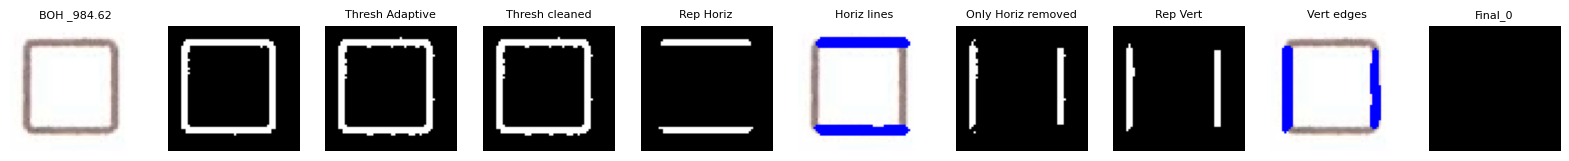

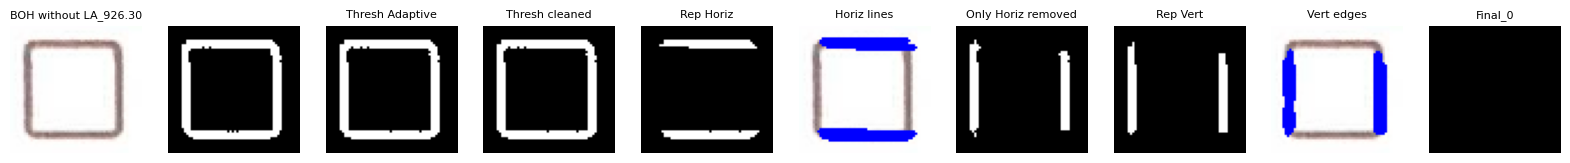

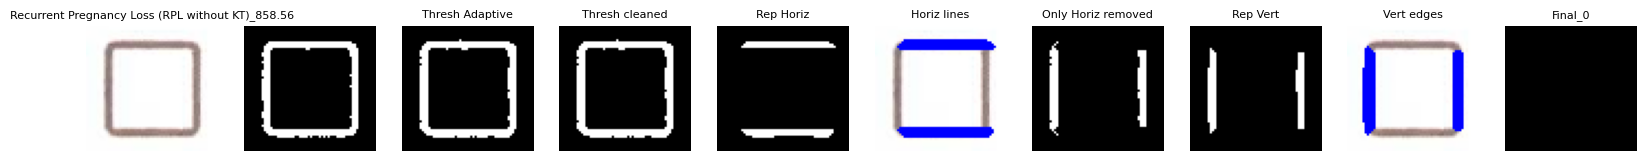

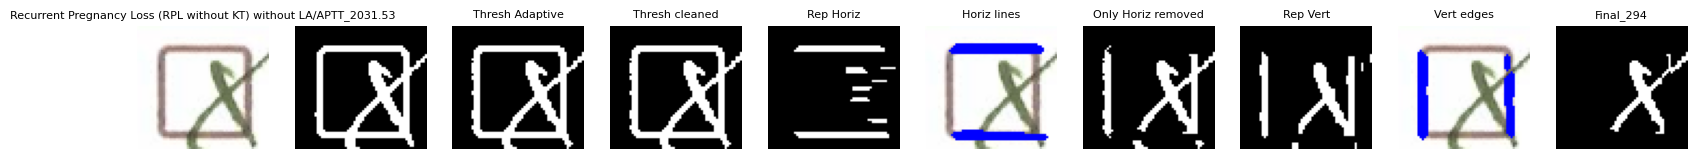

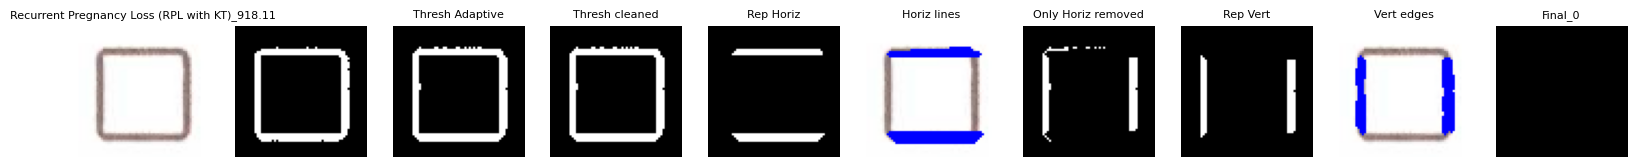

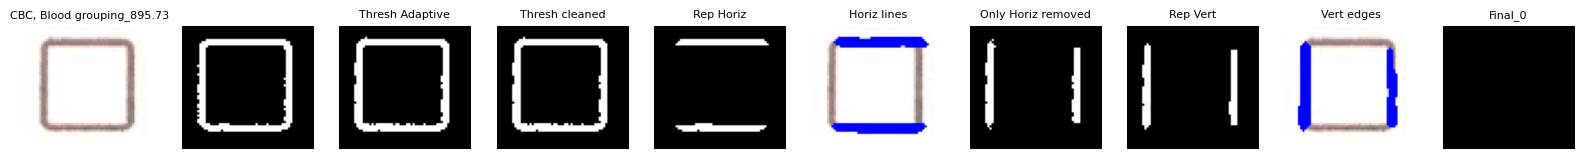

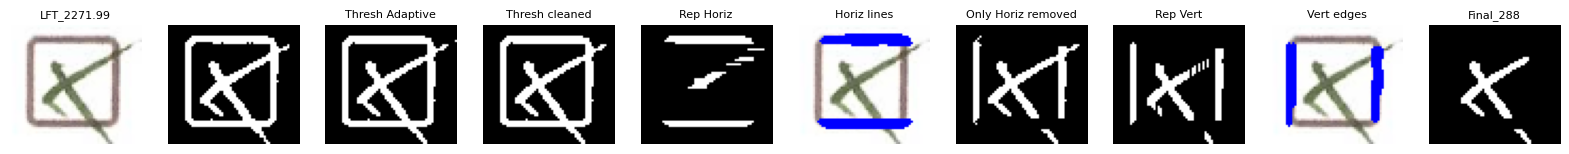

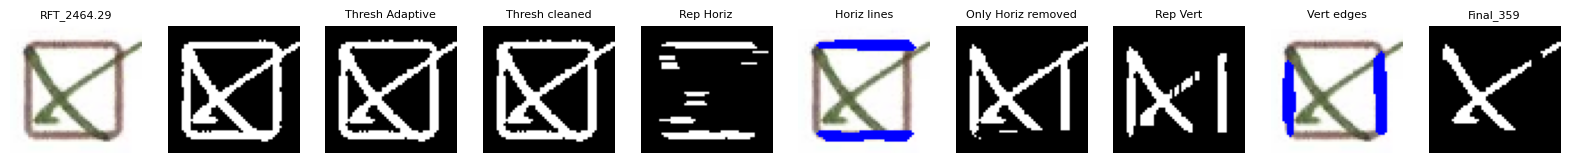

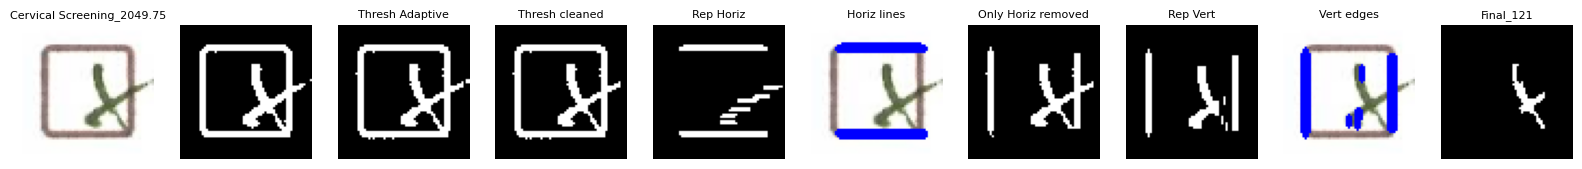

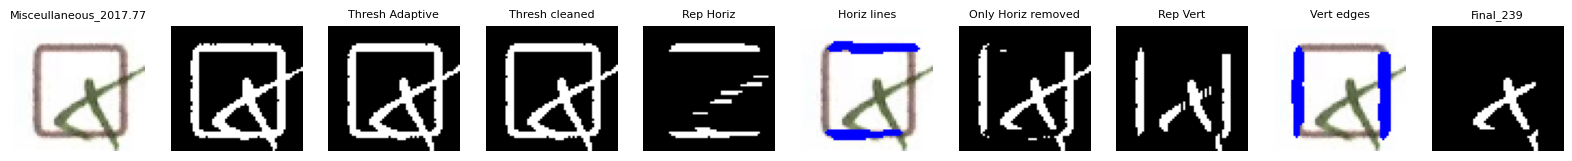

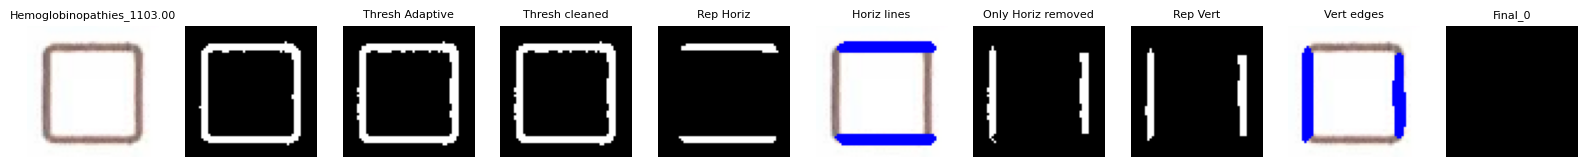

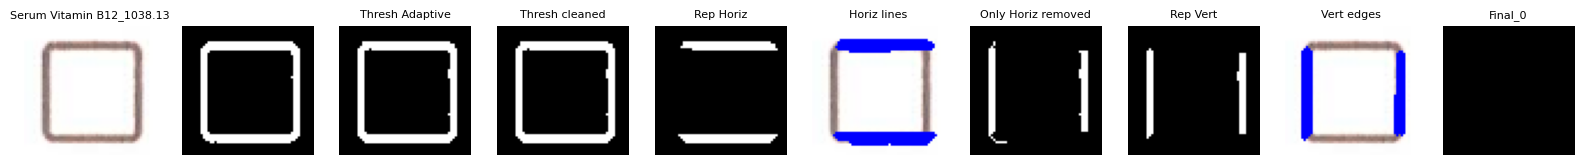

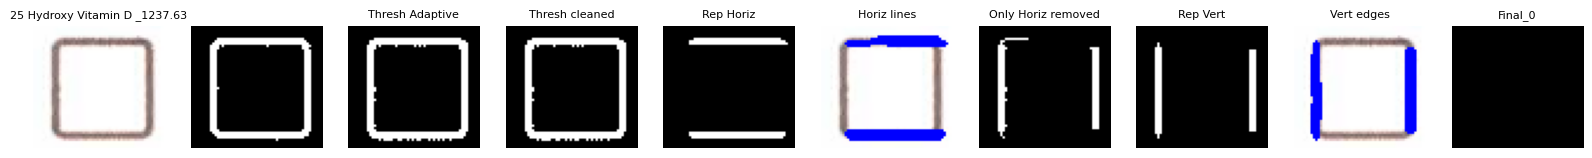

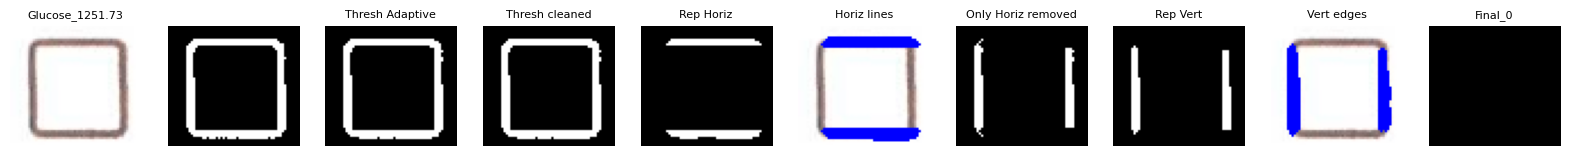

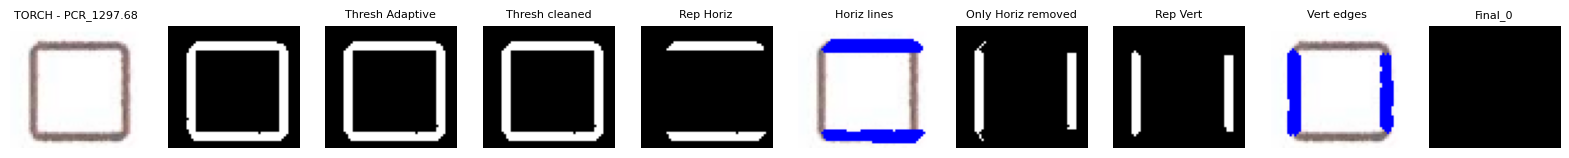

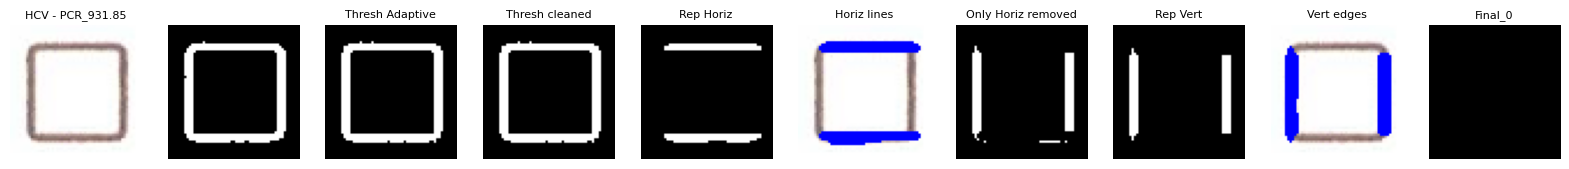

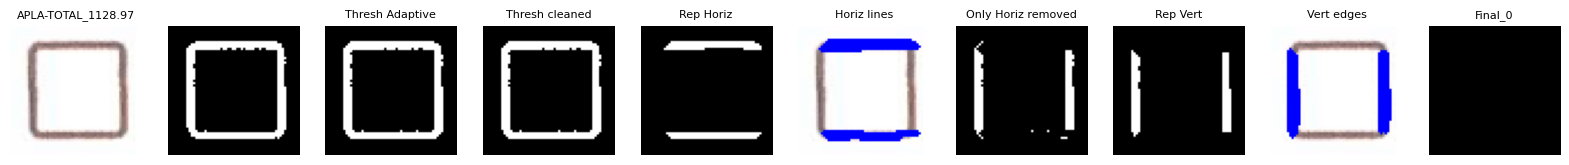

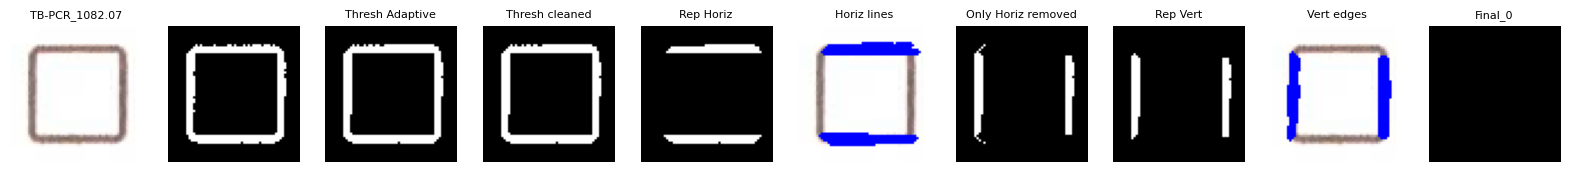

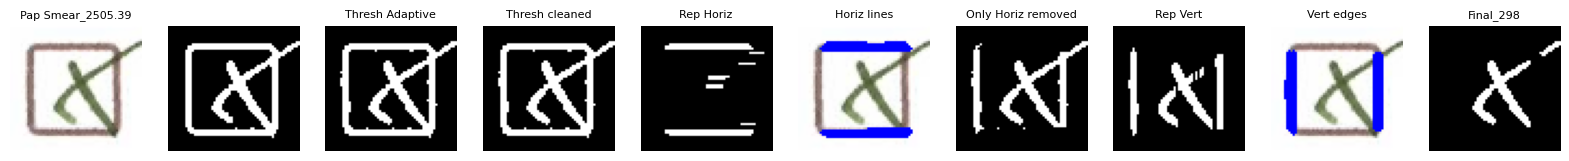

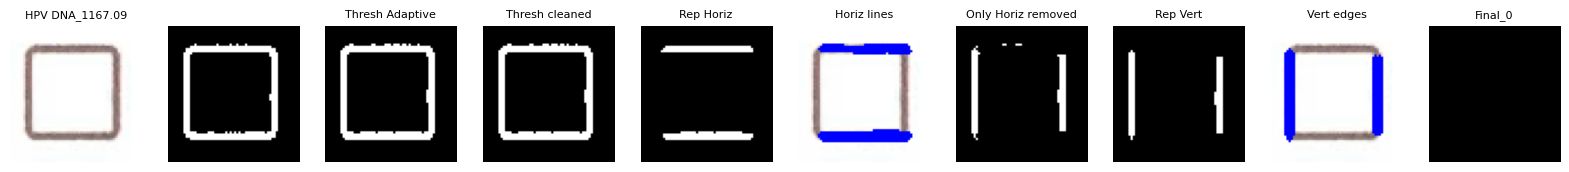

In [20]:

# https://stackoverflow.com/questions/55763858/how-to-detect-and-find-checkboxes-in-a-form-using-python-opencv


aligned_sift_copy_6 = aligned_sift.copy()

regions = []

SELECTION_COUNT_THRESHOLD = 0

for sample in lifecell_roi['data']['regions']:
    sample_shape = sample['shape_attributes']
    sample_region = sample['region_attributes']

    x = sample_shape['x']
    y = sample_shape['y']
    w = sample_shape['width']
    h = sample_shape['height']

    entity = sample_region["type"]

    im = aligned_sift_copy_6[y:y+h, x:x+w]
    laplacian_var = cv2.Laplacian(im, cv2.CV_64F).var()
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    
    plt.figure(figsize=(20, 10))

    ax1 = plt.subplot2grid((1,10), (0,0))
    ax1.set_title(f'{entity}_{laplacian_var:0.2f}', size=8)
    ax1.axis('off')
    ax1.imshow(im, cmap=plt.cm.gray)

    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    # thresh = 255 - thresh

    ax2 = plt.subplot2grid((1,10), (0,1))
    ax2.set_title("", size=8)
    ax2.axis('off')
    ax2.imshow(thresh_otsu, cmap=plt.cm.gray)
    
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 10)
    
    ax3 = plt.subplot2grid((1,10), (0,2))
    ax3.set_title("Thresh Adaptive", size=8)
    ax3.axis('off')
    ax3.imshow(thresh, cmap=plt.cm.gray)
    
    cnts, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
    AREA_THRESHOLD = 10
    for c in cnts:
        area = cv2.contourArea(c)
        if area < AREA_THRESHOLD:
            cv2.drawContours(thresh, [c], -1, 0, -1)

    ax4 = plt.subplot2grid((1,10), (0,3))
    ax4.set_title("Thresh cleaned", size=8)
    ax4.axis('off')
    ax4.imshow(thresh, cmap=plt.cm.gray)

    repair_kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 1))
    repair_horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, repair_kernel_horizontal, iterations=2)
    ax5 = plt.subplot2grid((1,10), (0,4))
    ax5.set_title("Rep Horiz", size=8)
    ax5.axis('off')
    ax5.imshow(repair_horizontal, cmap=plt.cm.gray)

    # lines = cv2.HoughLines(repair_horizontal,1, np.pi/180, 5, None, 0, 0, 0, 1 * 180 / np.pi)
    horizontal_lines = cv2.HoughLinesP(repair_horizontal, 1, np.pi/180, 20, 10, 10)

    im_copy_horiz = im.copy()

    if horizontal_lines is not None:
        for line in horizontal_lines:
            for x1, y1, x2, y2 in line:
                theta = np.arctan((y2 - y1) / (x2 - x1 + 1e-8)) * 180 / np.pi
                # print(f'Horizontal Entity: {sample_region["type"]}, x1: {x1}, y1: {y1}, x2: {x2}, y2: {y2}, theta: {theta}')
                if (theta > -6 and theta < 6):
                    cv2.line(thresh, (x1, y1), (x2, y2), (0, 0, 0), 2)
                    cv2.line(im_copy_horiz, (x1, y1), (x2, y2), (0, 0, 255), 2)

    ax6 = plt.subplot2grid((1,10), (0,5))
    ax6.set_title('Horiz lines', size=8)
    ax6.axis('off')
    ax6.imshow(im_copy_horiz, cmap=plt.cm.gray)
    
    ax7 = plt.subplot2grid((1,10), (0,6))
    ax7.set_title('Only Horiz removed', size=8)
    ax7.axis('off')
    ax7.imshow(thresh, cmap=plt.cm.gray)

    repair_kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 4))
    repair_vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, repair_kernel_vertical, iterations=1)
    vertical_edges = cv2.Canny(repair_vertical, 50, 200, apertureSize=3)
    vertical_lines = cv2.HoughLinesP(repair_vertical, 1, np.pi/180, 12, 40, 4)
    im_copy_vert = im.copy()

    if vertical_lines is not None:
        for line in vertical_lines:
            for x1, y1, x2, y2 in line:
                theta = np.abs(np.arctan((y2 - y1)/(x2 - x1 + 1e-8)) * 180 / np.pi)
                # print(f'Vertical: Entity: {sample_region["type"]}, x1: {x1}, y1: {y1}, x2: {x2}, y2: {y2}, theta: {theta}')
                if (theta > 84 and theta < 96):
                    cv2.line(thresh, (x1, y1), (x2, y2), (0, 0, 0), 2)
                    cv2.line(im_copy_vert, (x1, y1), (x2, y2), (0, 0, 255), 2)
    # else:
        # print(f'Vertical: Entity: {entity}, No Line Detected')



    ax8 = plt.subplot2grid((1,10), (0,7))
    ax8.set_title("Rep Vert", size=8)
    ax8.axis('off')
    ax8.imshow(repair_vertical, cmap=plt.cm.gray)

    ax9 = plt.subplot2grid((1,10), (0,8))
    ax9.set_title("Vert edges", size=8)
    ax9.axis('off')
    ax9.imshow(im_copy_vert, cmap=plt.cm.gray)


    # Cleaning the final image noise with contours
    cnts, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
    AREA_THRESHOLD = 10
    for c in cnts:
        area = cv2.contourArea(c)
        if area < AREA_THRESHOLD:
            cv2.drawContours(thresh, [c], -1, 0, -1)

    non_black_count = cv2.countNonZero(thresh)
    
    ax10 = plt.subplot2grid((1,10), (0,9))
    ax10.set_title(f"Final_{non_black_count}", size=8)
    ax10.axis('off')
    ax10.imshow(thresh, cmap=plt.cm.gray)

    if non_black_count > SELECTION_COUNT_THRESHOLD:
        regions.append(entity)



    
print("Entities Found: ", regions)
    